# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
!pip -q install pyverilog networkx matplotlib



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
demo_top = r"""
module chip_top(input clk, input rst_n, output [7:0] gpio_a, output [7:0] gpio_b);
  wire [7:0] A, B, Y_add, Y_xor;
  simple_rom u_rom (.addr(1'b0), .data(A));
  simple_rom u_rom2(.addr(1'b1), .data(B));
  simple_alu u_add (.a(A), .b(B), .op(2'b00), .y(Y_add));
  simple_alu u_xor (.a(A), .b(B), .op(2'b10), .y(Y_xor));
  assign gpio_a = Y_add;
  assign gpio_b = Y_xor;
endmodule
"""

demo_alu = r"""
module simple_alu(input [7:0] a, input [7:0] b, input [1:0] op, output reg [7:0] y);
  always @* begin
    case (op)
      2'b00: y = a + b;
      2'b10: y = a ^ b;
      default: y = a & b;
    endcase
  end
endmodule

module simple_rom(input [0:0] addr, output reg [7:0] data);
  always @* begin
    case (addr)
      1'b0: data = 8'h2A;
      1'b1: data = 8'h11;
      default: data = 8'h00;
    endcase
  end
endmodule
"""

with open("chip_top.v", "w") as f: f.write(demo_top)
with open("blocks.v", "w") as f: f.write(demo_alu)
print("Wrote chip_top.v and blocks.v")


Wrote chip_top.v and blocks.v


In [3]:
import networkx as nx
from pyverilog.vparser.parser import parse
from pyverilog.vparser.ast import (
    ModuleDef, InstanceList, Instance, PortArg,
    Identifier, Pointer, IntConst
)

def _stringify_conn(expr):
    if expr is None:
        return ""
    if isinstance(expr, Identifier):
        return expr.name
    if isinstance(expr, Pointer):     # e.g. data[3]
        base = _stringify_conn(expr.var)
        idx  = _stringify_conn(expr.ptr)
        return f"{base}[{idx}]"
    if isinstance(expr, IntConst):
        return expr.value
    return str(expr)

def _get_portarg_expr(carg):
    # Handle PyVerilog version differences: argname / arg / expr
    if hasattr(carg, "argname") and carg.argname is not None:
        return carg.argname
    if hasattr(carg, "arg") and carg.arg is not None:
        return carg.arg
    if hasattr(carg, "expr") and carg.expr is not None:
        return carg.expr
    return None

def _get_portarg_name(carg, idx):
    # Named .port(...) vs ordered connection
    if getattr(carg, "portname", None) is not None:
        return str(carg.portname)
    return f"_{idx}"

def build_netlist_graph(verilog_files, top=None, treat_top_ios_as_nets=True):
    ast, _ = parse(verilog_files)
    modules = {d.name: d for d in ast.description.definitions if isinstance(d, ModuleDef)}

    if top is None:
        if len(modules) != 1:
            raise ValueError(f"Specify top. Found modules: {list(modules)}")
        top = next(iter(modules))
    if top not in modules:
        raise ValueError(f"Top {top} not found. Available: {list(modules)}")

    top_mod = modules[top]
    G = nx.Graph()

    # Optional: add top I/O names as net nodes
    if treat_top_ios_as_nets and getattr(top_mod, "portlist", None):
        for p in (top_mod.portlist.ports or []):
            name = getattr(p, "name", None) or getattr(getattr(p, "first", None), "name", None)
            if name and not G.has_node(name):
                G.add_node(name, type="net", name=name, is_top_io=True, bipartite=1)

    # One-level instance scan in top module
    for item in getattr(top_mod, "items", []) or []:
        if not isinstance(item, InstanceList):
            continue
        child_mod = item.module
        for inst in item.instances or []:
            if not isinstance(inst, Instance):
                continue
            iname = inst.name
            if not G.has_node(iname):
                G.add_node(iname, type="instance", mod=child_mod, name=iname, bipartite=0, ports={})

            portlist = inst.portlist or []
            for idx, carg in enumerate(portlist):
                if not isinstance(carg, PortArg):
                    continue
                port = _get_portarg_name(carg, idx)
                expr = _get_portarg_expr(carg)
                net  = _stringify_conn(expr)
                if not net:
                    continue
                if not G.has_node(net):
                    G.add_node(net, type="net", name=net, is_top_io=False, bipartite=1)
                G.nodes[iname]["ports"][port] = net
                G.add_edge(iname, net, port=port)
    return G


CWD: c:\Users\abdul\PycharmProjects\JupyterProject
Here: ['FYP.ipynb', 'README.md', 'README_FRONTEND.md', 'SETUP.md', '__pycache__', 'backend', 'blocks.v', 'chip_top.v', 'chip_top_long.v', 'data', 'export_def.py', 'frontend', 'inject_instances_nets.py', 'mini.v', 'models', 'netlist_parser.py', 'newfile.v', 'out', 'parser.out', 'parsetab.py', 'patch_notebook.py', 'placement_results.json', 'ppo_final_placement.plc', 'requirements.txt', 'sample.ipynb']
Has chip_top.v: True
Has blocks.v  : True

--- chip_top.v (first 12 lines) ---

module chip_top(input clk, input rst_n, output [7:0] gpio_a, output [7:0] gpio_b);
  wire [7:0] A, B, Y_add, Y_xor;
  simple_rom u_rom (.addr(1'b0), .data(A));
  simple_rom u_rom2(.addr(1'b1), .data(B));
  simple_alu u_add (.a(A), .b(B), .op(2'b00), .y(Y_add));
  simple_alu u_xor (.a(A), .b(B), .op(2'b10), .y(Y_xor));
  assign gpio_a = Y_add;
  assign gpio_b = Y_xor;
endmodule

--- blocks.v (first 12 lines) ---

module simple_alu(input [7:0] a, input [7:0] b, in

Generating LALR tables


Modules found: ['chip_top', 'simple_alu', 'simple_rom']
Instances: 4
Nets     : 12
Edges    : 12


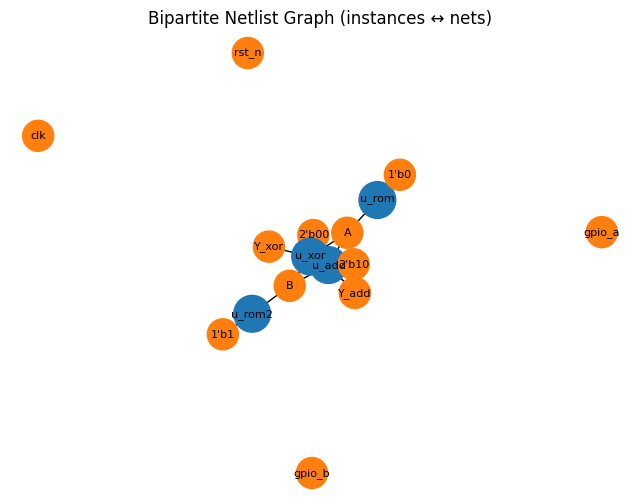

In [4]:
# --- DIAGNOSTIC + BUILD + PLOT (PyVerilog) ---
import os, glob, json, sys, traceback
import networkx as nx
import matplotlib.pyplot as plt

print("CWD:", os.getcwd())
print("Here:", sorted(glob.glob("*")))
print("Has chip_top.v:", os.path.exists("chip_top.v"))
print("Has blocks.v  :", os.path.exists("blocks.v"))

# 1) Show first few lines (sanity)
def head(path, n=12):
    if os.path.exists(path):
        with open(path, "r") as f:
            print(f"\n--- {path} (first {n} lines) ---")
            for i, line in enumerate(f):
                if i >= n: break
                print(line.rstrip())
    else:
        print(f"\n!! Missing file: {path}")

head("chip_top.v")
head("blocks.v")

# 2) Robust parser (handles PortArg .arg/.argname/.expr)
from pyverilog.vparser.parser import parse
from pyverilog.vparser.ast import (
    ModuleDef, InstanceList, Instance, PortArg,
    Identifier, Pointer, IntConst
)

def _stringify_conn(expr):
    if expr is None: return ""
    if isinstance(expr, Identifier): return expr.name
    if isinstance(expr, Pointer):
        base = _stringify_conn(expr.var)
        idx  = _stringify_conn(expr.ptr)
        return f"{base}[{idx}]"
    if isinstance(expr, IntConst): return expr.value
    return str(expr)

def _get_portarg_expr(carg):
    for attr in ("argname","arg","expr"):
        if hasattr(carg, attr) and getattr(carg, attr) is not None:
            return getattr(carg, attr)
    return None

def _get_portarg_name(carg, idx):
    return str(carg.portname) if getattr(carg, "portname", None) is not None else f"_{idx}"

def build_netlist_graph(verilog_files, top=None, treat_top_ios_as_nets=True):
    ast, directives = parse(verilog_files)
    modules = {d.name: d for d in ast.description.definitions if isinstance(d, ModuleDef)}
    print("Modules found:", list(modules.keys()))
    if top is None:
        if len(modules) != 1:
            raise ValueError(f"Specify top. Found modules: {list(modules)}")
        top = next(iter(modules))
    if top not in modules:
        raise ValueError(f"Top {top} not in modules: {list(modules)}")

    top_mod = modules[top]
    G = nx.Graph()

    # add top IOs as nets
    if treat_top_ios_as_nets and getattr(top_mod, "portlist", None):
        for p in (top_mod.portlist.ports or []):
            name = getattr(p, "name", None) or getattr(getattr(p, "first", None), "name", None)
            if name and not G.has_node(name):
                G.add_node(name, type="net", name=name, is_top_io=True, bipartite=1)

    # scan instances (one level)
    for item in getattr(top_mod, "items", []) or []:
        if not isinstance(item, InstanceList): continue
        child_mod = item.module
        for inst in item.instances or []:
            if not isinstance(inst, Instance): continue
            iname = inst.name
            if not G.has_node(iname):
                G.add_node(iname, type="instance", mod=child_mod, name=iname, bipartite=0, ports={})
            for idx, carg in enumerate(inst.portlist or []):
                if not isinstance(carg, PortArg): continue
                port = _get_portarg_name(carg, idx)
                expr = _get_portarg_expr(carg)
                net  = _stringify_conn(expr)
                if not net: continue
                if not G.has_node(net):
                    G.add_node(net, type="net", name=net, is_top_io=False, bipartite=1)
                G.nodes[iname]["ports"][port] = net
                G.add_edge(iname, net, port=port)

    return G

# 3) Build
try:
    G = build_netlist_graph(["chip_top.v", "blocks.v"], top="chip_top")
    print("Instances:", sum(1 for _, d in G.nodes(data=True) if d["type"]=="instance"))
    print("Nets     :", sum(1 for _, d in G.nodes(data=True) if d["type"]=="net"))
    print("Edges    :", G.number_of_edges())

    # 4) Plot
    pos = nx.spring_layout(G, seed=7)
    colors = ["tab:blue" if d["type"]=="instance" else "tab:orange" for _,d in G.nodes(data=True)]
    sizes  = [700 if d["type"]=="instance" else 500 for _,d in G.nodes(data=True)]
    plt.figure(figsize=(8,6))
    nx.draw_networkx(G, pos=pos, node_color=colors, node_size=sizes, with_labels=True, font_size=8)
    plt.axis("off"); plt.title("Bipartite Netlist Graph (instances ↔ nets)")
    plt.show()

except Exception as e:
    print("\nPyVerilog path failed:")
    traceback.print_exc()
    print("\nIf this persists, use Option B (pure-Python hdlConvertor) below.")


In [5]:
# ---------- In-notebook netlist extraction and DEF/LEF export (no netlist_parser dependency) ----------
import os

def extract_netlist(G, top_module):
    """Extract instances and nets from the netlist graph. Returns (instances_list, nets_dict)."""
    if G is None:
        raise ValueError("extract_netlist: G must not be None (run netlist build cell first).")
    instances_list = []
    for node, data in G.nodes(data=True):
        if data.get("type") == "instance":
            mod = data.get("mod", "unknown")
            m = mod if isinstance(mod, str) else getattr(mod, "name", str(mod))
            instances_list.append({"name": node, "type": m})
    nets_dict = {}
    for node, data in G.nodes(data=True):
        if data.get("type") != "net":
            continue
        pins = []
        for neighbor in G.neighbors(node):
            if G.nodes[neighbor].get("type") != "instance":
                continue
            edge_data = G.get_edge_data(node, neighbor)
            if edge_data and "port" in edge_data:
                port = edge_data["port"]
                p = port if isinstance(port, str) else getattr(port, "name", str(port))
                pins.append({"inst": neighbor, "pin": p})
        nets_dict[node] = pins
    return instances_list, nets_dict

def write_lef(lef_path, dbu_per_micron=100, macro_sizes=None, pin_defs=None):
    """Write minimal LEF for OpenROAD: simple_rom and simple_alu with pins (addr, data / a, b, op, y)."""
    macro_sizes = macro_sizes or {"simple_rom": (4000, 4000), "simple_alu": (4000, 4000)}
    pin_defs = pin_defs or {"simple_rom": ["addr", "data"], "simple_alu": ["a", "b", "op", "y"]}
    os.makedirs(os.path.dirname(lef_path) or ".", exist_ok=True)
    lines = [
        "VERSION 5.8 ;", "NAMESCASESENSITIVE ON ;", f"UNITS DATABASE MICRONS {dbu_per_micron} ;", "",
        "SITE CORE", "  CLASS CORE ;", "  SIZE 1.000 BY 1.000 ;", "END CORE", "",
        "LAYER M1", "  TYPE ROUTING ;", "  DIRECTION HORIZONTAL ;", "  PITCH 100 100 ;", "  WIDTH 100 ;", "END M1", "",
    ]
    for macro_name in ("simple_rom", "simple_alu"):
        w_dbu, h_dbu = macro_sizes.get(macro_name, (4000, 4000))
        w_um, h_um = w_dbu / dbu_per_micron, h_dbu / dbu_per_micron
        pins = pin_defs.get(macro_name, [])
        lines.extend([f"MACRO {macro_name}", "  CLASS BLOCK ;", f"  FOREIGN {macro_name} 0.000 0.000 ;", f"  SIZE {w_um:.3f} BY {h_um:.3f} ;", ""])
        for i, p in enumerate(pins):
            if i % 4 == 0:   x, y = 0, int(h_dbu * (0.2 + 0.2 * (i // 4)))
            elif i % 4 == 1: x, y = w_dbu - 100, int(h_dbu * (0.2 + 0.2 * (i // 4)))
            elif i % 4 == 2: x, y = int(w_dbu * (0.2 + 0.2 * (i // 4))), 0
            else:             x, y = int(w_dbu * (0.2 + 0.2 * (i // 4))), h_dbu - 100
            x2_um, y2_um = (x + 100) / dbu_per_micron, (y + 100) / dbu_per_micron
            x_um, y_um = x / dbu_per_micron, y / dbu_per_micron
            lines.extend([f"  PIN {p}", "    DIRECTION INOUT ;", "    USE SIGNAL ;", "    PORT", "      LAYER M1 ;", f"      RECT {x_um:.3f} {y_um:.3f} {x2_um:.3f} {y2_um:.3f} ;", "    END", f"  END {p}", ""])
        lines.append("END " + macro_name); lines.append("")

    with open(lef_path, "w") as f:
        f.write("\n".join(lines))

def write_def(def_path, design_name, H, W, scale, instances, placements, nets):
    """Write DEF with COMPONENTS (master = instance type) and NETS (nets with >= 2 instance pins)."""
    os.makedirs(os.path.dirname(def_path) or ".", exist_ok=True)
    inst_by_name = {i["name"]: i for i in instances}
    die_w, die_h = W * scale, H * scale
    lines = [
        "VERSION 5.8 ;", 'DIVIDERCHAR "/" ;', 'BUSBITCHARS "[]" ;', f"DESIGN {design_name} ;",
        "UNITS DISTANCE MICRONS 100 ;", f"DIEAREA ( 0 0 ) ( {die_w} {die_h} ) ;", "", f"COMPONENTS {len(placements)} ;",
    ]
    for inst_name, box in placements.items():
        master = inst_by_name.get(inst_name, {}).get("type", "macro")
        if not isinstance(master, str): master = getattr(master, "name", "macro")
        y, x, h, w = box
        x_def, y_def = x * scale, y * scale
        lines.append(f"  - {inst_name} {master} + PLACED ( {x_def} {y_def} ) N ;")
    lines.append("END COMPONENTS"); lines.append("")

    nets_to_write = []
    for net_name, pins in (nets or {}).items():
        conns = [p for p in pins if isinstance(p, dict) and p.get("inst") in placements]
        if len(conns) >= 2:
            nets_to_write.append((net_name, conns))
    lines.append(f"NETS {len(nets_to_write)} ;")
    for net_name, conns in nets_to_write:
        parts = [f"  - {net_name}"] + [f" ( {c['inst']} {c['pin']} )" for c in conns] + [" ;"]
        lines.append("".join(parts))
    lines.append("END NETS"); lines.append(""); lines.append("END DESIGN")
    with open(def_path, "w") as f:
        f.write("\n".join(lines))

In [6]:
# Use the in-memory graph G if you have it; else load the JSON we saved earlier.
import json, os, networkx as nx

if "G" in globals():
    G_src = G
else:
    with open("netlist_demo.json") as f:
        data = json.load(f)
    G_src = nx.Graph()
    for inst in data["instances"]:
        G_src.add_node(inst["name"], type="instance", mod=inst["mod"], ports=inst["ports"])
    for net in data["nets"]:
        G_src.add_node(net["name"], type="net")
    for e in data["edges"]:
        G_src.add_edge(e["instance"], e["net"], port=e["port"])

instances_list, nets_dict = extract_netlist(G_src, "chip_top")
instances = [x["name"] for x in instances_list]
nets = list(nets_dict.keys())
multi_pin = [k for k, v in nets_dict.items() if len(v) >= 2]
print("Extraction summary: instances =", len(instances_list), ", nets =", len(nets_dict), ", multi-pin nets =", multi_pin)


Extraction summary: instances = 4 , nets = 12 , multi-pin nets = ['A', 'B']


In [7]:
import numpy as np
rng = np.random.default_rng(7)

# Grid size (keep small for now)
H, W = 24, 24   # rows (y), cols (x)

# Assign simple macro sizes (in grid cells) — tweak as you like
# Here: ALUs are 4x3, ROMs 5x4, others 3xA3 default
sizes = {}
for inst in instances:
    mod = G_src.nodes[inst].get("mod","").lower()
    if "alu" in mod:
        sizes[inst] = (4,3)
    elif "rom" in mod or "sram" in mod:
        sizes[inst] = (5,4)
    else:
        sizes[inst] = (3,3)

# Occupancy grid (0=free, 1=occupied)
occ = np.zeros((H, W), dtype=np.uint8)

def fits(y, x, h, w):
    if y<0 or x<0 or y+h>H or x+w>W:
        return False
    return np.all(occ[y:y+h, x:x+w] == 0)

def place_rect(y, x, h, w):
    occ[y:y+h, x:x+w] = 1

# Simple legal random placement (retry a few times for each inst)
placements = {}  # inst -> (y, x, h, w) top-left on grid
for inst in instances:
    h, w = sizes[inst]
    placed = False
    for _ in range(2000):
        y = int(rng.integers(0, H-h))
        x = int(rng.integers(0, W-w))
        if fits(y, x, h, w):
            place_rect(y, x, h, w)
            placements[inst] = (y, x, h, w)
            placed = True
            break
    if not placed:
        raise RuntimeError(f"Could not place {inst}; try smaller sizes or a larger grid.")

print("Placed:", placements)


Placed: {'u_rom': (17, 12, 5, 4), 'u_rom2': (12, 17, 5, 4), 'u_add': (16, 4, 4, 3), 'u_xor': (1, 6, 4, 3)}


In [8]:
%pip install scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Build net -> list of instance centers it touches (ignore top IO-only nets for now)
def rect_center(y,x,h,w):
    return (y + h/2.0, x + w/2.0)

net_to_points = {}
for net in nets:
    pts = []
    # neighbors of net are instances (bipartite)
    for nbr in G_src.neighbors(net):
        if G_src.nodes[nbr].get("type")=="instance" and nbr in placements:
            y,x,h,w = placements[nbr]
            pts.append(rect_center(y,x,h,w))
    if len(pts) >= 1:
        net_to_points[net] = pts

# HPWL
def hpwl_for_net(points):
    ys = [p[0] for p in points]
    xs = [p[1] for p in points]
    return (max(xs)-min(xs)) + (max(ys)-min(ys))

hpwl_total = sum(hpwl_for_net(pts) for pts in net_to_points.values() if len(pts)>=2)
print(f"HPWL ≈ {hpwl_total:.2f}")

# Very simple L-shaped routing congestion (just for a feel)
cong = np.zeros_like(occ, dtype=np.int32)
for pts in net_to_points.values():
    if len(pts) < 2:
        continue
    # connect each point to the first one with an L route
    y0,x0 = pts[0]
    y0,x0 = int(round(y0)), int(round(x0))
    for (y1,x1) in pts[1:]:
        y1,x1 = int(round(y1)), int(round(x1))
        # horizontal then vertical
        xlo, xhi = sorted([x0,x1])
        ylo, yhi = sorted([y0,y1])
        cong[y0, xlo:xhi+1] += 1
        cong[ylo:yhi+1, x1] += 1

# Smooth (5x1 + 1x5)
from scipy.ndimage import convolve1d
cong_s = convolve1d(cong, np.ones(5)/5.0, axis=0, mode="nearest")
cong_s = convolve1d(cong_s, np.ones(5)/5.0, axis=1, mode="nearest")

# Congestion score = mean of top 10%
flat = cong_s.flatten()
k = max(1, int(0.10*flat.size))
cong_score = float(np.mean(np.sort(flat)[-k:]))
print(f"Congestion (top10%) ≈ {cong_score:.3f}")


HPWL ≈ 53.50
Congestion (top10%) ≈ 0.000


In [10]:
# Build net -> list of instance centers it touches (ignore top IO-only nets for now)
def rect_center(y,x,h,w):
    return (y + h/2.0, x + w/2.0)

net_to_points = {}
for net in nets:
    pts = []
    # neighbors of net are instances (bipartite)
    for nbr in G_src.neighbors(net):
        if G_src.nodes[nbr].get("type")=="instance" and nbr in placements:
            y,x,h,w = placements[nbr]
            pts.append(rect_center(y,x,h,w))
    if len(pts) >= 1:
        net_to_points[net] = pts

# HPWL
def hpwl_for_net(points):
    ys = [p[0] for p in points]
    xs = [p[1] for p in points]
    return (max(xs)-min(xs)) + (max(ys)-min(ys))

hpwl_total = sum(hpwl_for_net(pts) for pts in net_to_points.values() if len(pts)>=2)
print(f"HPWL ≈ {hpwl_total:.2f}")

# Very simple L-shaped routing congestion (just for a feel)
cong = np.zeros_like(occ, dtype=np.int32)
for pts in net_to_points.values():
    if len(pts) < 2:
        continue
    # connect each point to the first one with an L route
    y0,x0 = pts[0]
    y0,x0 = int(round(y0)), int(round(x0))
    for (y1,x1) in pts[1:]:
        y1,x1 = int(round(y1)), int(round(x1))
        # horizontal then vertical
        xlo, xhi = sorted([x0,x1])
        ylo, yhi = sorted([y0,y1])
        cong[y0, xlo:xhi+1] += 1
        cong[ylo:yhi+1, x1] += 1

# Smooth (5x1 + 1x5)
from scipy.ndimage import convolve1d
cong_s = convolve1d(cong, np.ones(5)/5.0, axis=0, mode="nearest")
cong_s = convolve1d(cong_s, np.ones(5)/5.0, axis=1, mode="nearest")

# Congestion score = mean of top 10%
flat = cong_s.flatten()
k = max(1, int(0.10*flat.size))
cong_score = float(np.mean(np.sort(flat)[-k:]))
print(f"Congestion (top10%) ≈ {cong_score:.3f}")


HPWL ≈ 53.50
Congestion (top10%) ≈ 0.000


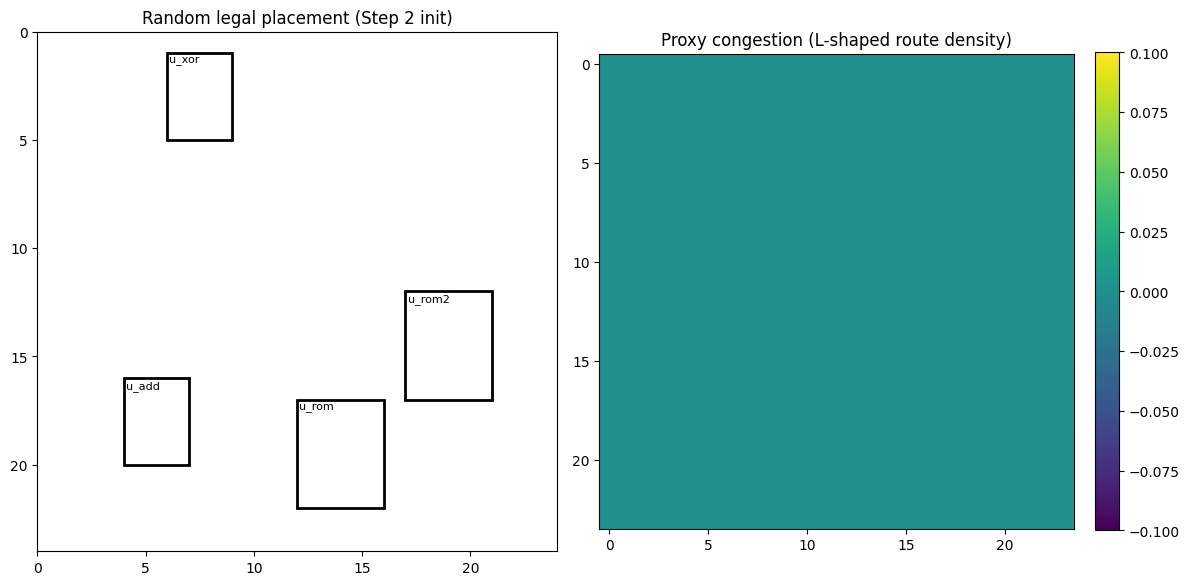

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Left: placement
ax[0].imshow(np.zeros_like(occ), cmap="gray_r", vmin=0, vmax=1)
for inst,(y,x,h,w) in placements.items():
    ax[0].add_patch(Rectangle((x,y), w,h, fill=False, lw=2))
    ax[0].text(x+0.1, y+0.1, inst, fontsize=8, ha="left", va="top")
ax[0].set_xlim(0,W); ax[0].set_ylim(H,0)
ax[0].set_title("Random legal placement (Step 2 init)")

# Right: congestion
im = ax[1].imshow(cong_s, origin="upper")
ax[1].set_title("Proxy congestion (L-shaped route density)")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


In [12]:
import numpy as np

# Helper maps
inst_to_nets = {i: [] for i in instances}
for net in nets:
    for nbr in G_src.neighbors(net):
        if G_src.nodes[nbr].get("type") == "instance":
            inst_to_nets[nbr].append(net)

# Reusable utils
def rect_center(y,x,h,w): return (y + h/2.0, x + w/2.0)

def hpwl_points(points):
    if len(points) < 2: return 0.0
    ys = [p[0] for p in points]; xs = [p[1] for p in points]
    return (max(xs) - min(xs)) + (max(ys) - min(ys))

def hpwl_total_from_placements(plc):
    # compute HPWL over all nets using placed instances only
    total = 0.0
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type") == "instance" and nbr in plc:
                y,x,h,w = plc[nbr]
                pts.append(rect_center(y,x,h,w))
        total += hpwl_points(pts)
    return total

# Fresh empty occupancy & placements
occ_g = np.zeros((H, W), dtype=np.uint8)
placements_greedy = {}

def fits(y, x, h, w):
    if y<0 or x<0 or y+h>H or x+w>W: return False
    return np.all(occ_g[y:y+h, x:x+w] == 0)

def place_rect(y, x, h, w): occ_g[y:y+h, x:x+w] = 1

# Order: bigger & more connected first
order = sorted(instances, key=lambda i: (sizes[i][0]*sizes[i][1], len(inst_to_nets[i])), reverse=True)

# Candidate sampling step to keep it fast (try every Kth grid cell)
K = 2  # smaller K = denser search, slower but better
best_hpwl_running = 0.0

for inst in order:
    h, w = sizes[inst]
    best = None
    # Search candidate cells
    for y in range(0, H-h+1, K):
        for x in range(0, W-w+1, K):
            if not fits(y, x, h, w):
                continue
            # Tentative placement
            tmp = dict(placements_greedy)
            tmp[inst] = (y, x, h, w)
            # Compute incremental HPWL only on nets touching 'inst'
            inc = 0.0
            for net in inst_to_nets[inst]:
                pts = []
                for nbr in G_src.neighbors(net):
                    if G_src.nodes[nbr].get("type")!="instance":
                        continue
                    if nbr == inst:
                        pts.append(rect_center(y, x, h, w))
                    elif nbr in placements_greedy:
                        y2,x2,h2,w2 = placements_greedy[nbr]
                        pts.append(rect_center(y2,x2,h2,w2))
                inc += hpwl_points(pts)
            # Track best
            if best is None or inc < best[0]:
                best = (inc, y, x)
    if best is None:
        raise RuntimeError(f"Could not place {inst} greedily; enlarge grid or lower sizes.")
    _, yb, xb = best
    place_rect(yb, xb, h, w)
    placements_greedy[inst] = (yb, xb, h, w)

hpwl_greedy = hpwl_total_from_placements(placements_greedy)
print("Greedy HPWL ≈", round(hpwl_greedy, 3))


Greedy HPWL ≈ 19.0


Random   -> HPWL: 53.50 | Cong(top10%): 1.404
Greedy   -> HPWL: 19.00 | Cong(top10%): 0.702


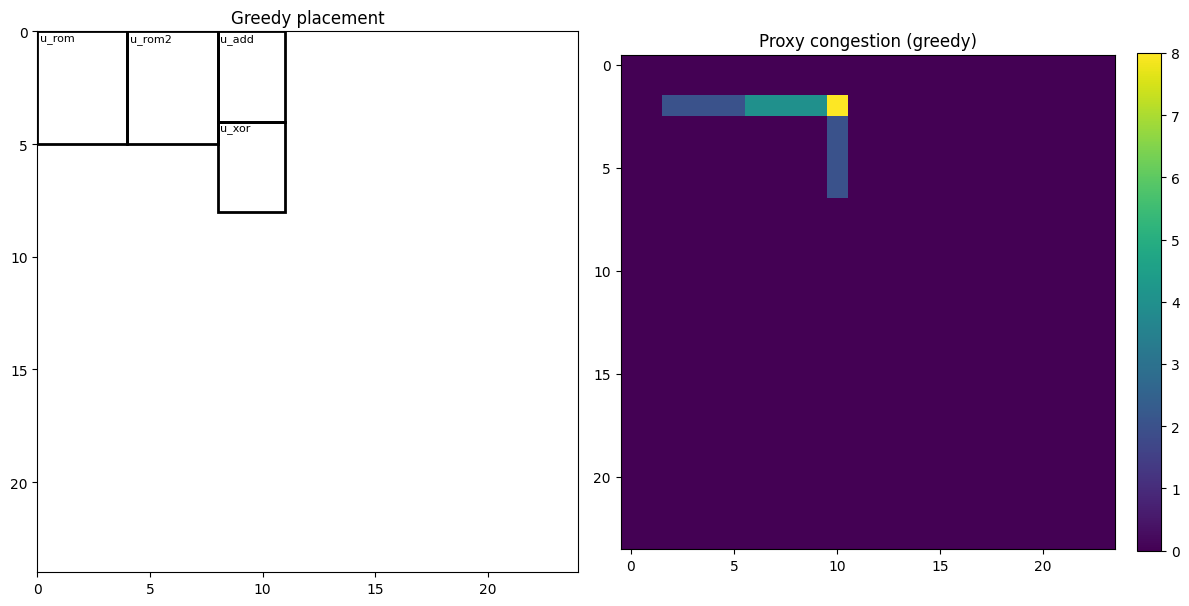

In [13]:
# Recompute random metrics using previous 'placements' (from Cell B/C)
def compute_congestion(plc):
    cong = np.zeros((H, W), dtype=np.int32)
    # net -> points
    def center_for(i):
        y,x,h,w = plc[i]
        return (int(round(y + h/2.0)), int(round(x + w/2.0)))
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type")=="instance" and nbr in plc:
                pts.append(center_for(nbr))
        if len(pts) < 2:
            continue
        y0,x0 = pts[0]
        for (y1,x1) in pts[1:]:
            xlo,xhi = sorted([x0,x1]); ylo,yhi = sorted([y0,y1])
            cong[y0, xlo:xhi+1] += 1
            cong[ylo:yhi+1, x1] += 1
    return cong.astype(float)

def cong_score_from(cong_map):
    flat = cong_map.flatten()
    k = max(1, int(0.10 * flat.size))
    return float(np.mean(np.sort(flat)[-k:]))

# Random (from earlier)
cong_r = compute_congestion(placements)
score_r = cong_score_from(cong_r)
hpwl_r = hpwl_total_from_placements(placements)

# Greedy
cong_g = compute_congestion(placements_greedy)
score_g = cong_score_from(cong_g)

print(f"Random   -> HPWL: {hpwl_r:.2f} | Cong(top10%): {score_r:.3f}")
print(f"Greedy   -> HPWL: {hpwl_greedy:.2f} | Cong(top10%): {score_g:.3f}")

# Plot greedy placement + congestion
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Greedy placement
ax[0].imshow(np.zeros((H,W)), cmap="gray_r", vmin=0, vmax=1)
for inst,(y,x,h,w) in placements_greedy.items():
    ax[0].add_patch(Rectangle((x,y), w,h, fill=False, lw=2))
    ax[0].text(x+0.1, y+0.1, inst, fontsize=8, ha="left", va="top")
ax[0].set_xlim(0,W); ax[0].set_ylim(H,0)
ax[0].set_title("Greedy placement")

# Greedy congestion
im = ax[1].imshow(cong_g, origin="upper")
ax[1].set_title("Proxy congestion (greedy)")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


In [14]:
import json, time
out = {
    "grid": {"H": H, "W": W},
    "sizes": sizes,
    "instances": instances_list,
    "nets": nets_dict,
    "placements_random": placements,
    "placements_greedy": placements_greedy,
    "metrics": {
        "random": {"hpwl": float(hpwl_r), "congestion_top10": float(score_r)},
        "greedy": {"hpwl": float(hpwl_greedy), "congestion_top10": float(score_g)},
    },
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
}
with open("placement_results.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved: placement_results.json")


Saved: placement_results.json


In [15]:
%pip install gymnasium sb3-contrib stable-baselines3 torch --upgrade


  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

def rect_center(y,x,h,w): return (y + h/2.0, x + w/2.0)

def hpwl_points(points):
    if len(points) < 2: return 0.0
    ys = [p[0] for p in points]; xs = [p[1] for p in points]
    return (max(xs)-min(xs)) + (max(ys)-min(ys))

def hpwl_total_from_placements(plc, nets, G_src):
    total = 0.0
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type")=="instance" and nbr in plc:
                y,x,h,w = plc[nbr]
                pts.append(rect_center(y,x,h,w))
        total += hpwl_points(pts)
    return total

def compute_congestion(plc, H, W, nets, G_src):
    cong = np.zeros((H, W), dtype=np.int32)
    def center_for(i):
        y,x,h,w = plc[i]
        return (int(round(y + h/2.0)), int(round(x + w/2.0)))
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get("type")=="instance" and nbr in plc:
                pts.append(center_for(nbr))
        if len(pts) < 2: continue
        y0,x0 = pts[0]
        for (y1,x1) in pts[1:]:
            xlo,xhi = sorted([x0,x1]); ylo,yhi = sorted([y0,y1])
            cong[y0, xlo:xhi+1] += 1
            cong[ylo:yhi+1, x1] += 1
    return cong.astype(float)

def congestion_score(cong_map):
    flat = cong_map.flatten()
    k = max(1, int(0.10 * flat.size))
    return float(np.mean(np.sort(flat)[-k:]))

class PlacementEnv(gym.Env):
    """
    Observation: Dict(
      canvas: (H,W) occupancy 0/1,
      cur: (4,) [h, w, norm_deg, idx_norm],
      mask: (H*W,) bool legal-action mask  (returned via .info for MaskablePPO)
    )
    Action: Discrete(H*W) -> place current instance's top-left at (y,x).
    Reward: 0 until terminal; at the end: -(HPWL + λ * congestion).
    """
    metadata = {"render_modes": []}

    def __init__(self, instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.01, seed=7):
        super().__init__()
        self.instances = list(instances)
        # Order bigger & more connected first (helps learning)
        deg = {i: sum(1 for _ in G_src.neighbors(i) if G_src.nodes[_].get("type")=="net") for i in self.instances}
        self.order = sorted(self.instances, key=lambda i: (sizes[i][0]*sizes[i][1], deg[i]), reverse=True)
        self.nets = list(nets)
        self.sizes = dict(sizes)
        self.G_src = G_src
        self.H, self.W = H, W
        self.lam = lam_cong
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Discrete(self.H * self.W)
        self.observation_space = spaces.Dict({
            "canvas": spaces.Box(0, 1, shape=(self.H, self.W), dtype=np.uint8),
            "cur":    spaces.Box(low=0.0, high=1.0, shape=(4,), dtype=np.float32),
        })

        # precompute degrees
        self.deg = deg
        self.reset(seed=seed)

    def _fits(self, y, x, h, w):
        if y<0 or x<0 or y+h>self.H or x+w>self.W: return False
        return np.all(self.occ[y:y+h, x:x+w] == 0)

    def _mask(self):
        """Boolean mask over flattened grid; True = legal."""
        mask = np.zeros(self.H*self.W, dtype=bool)
        if self.idx >= len(self.order):  # terminal
            return mask
        inst = self.order[self.idx]
        h, w = self.sizes[inst]
        for y in range(self.H - h + 1):
            row = y * self.W
            for x in range(self.W - w + 1):
                if self._fits(y, x, h, w):
                    mask[row + x] = True
        return mask

    def _obs(self):
        # normalize degree by max degree in this netlist
        maxd = max(1, max(self.deg.values()))
        if self.idx < len(self.order):
            inst = self.order[self.idx]
            h, w = self.sizes[inst]
            cur = np.array([h/self.H, w/self.W, self.deg[inst]/maxd, self.idx/max(1,len(self.order)-1)], dtype=np.float32)
        else:
            cur = np.zeros(4, dtype=np.float32)
        return {"canvas": self.occ.copy(), "cur": cur}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.occ = np.zeros((self.H, self.W), dtype=np.uint8)
        self.idx = 0
        self.placements = {}  # inst -> (y,x,h,w)
        obs = self._obs()
        info = {"action_mask": self._mask()}
        return obs, info

    def step(self, action):
        assert self.action_space.contains(action)
        done = False
        reward = 0.0

        # current inst
        if self.idx >= len(self.order):
            # Already terminal
            return self._obs(), 0.0, True, False, {"action_mask": self._mask()}

        inst = self.order[self.idx]
        h, w = self.sizes[inst]
        y, x = divmod(action, self.W)

        # illegal action: give small penalty and continue (maskable PPO should avoid these)
        if not self._fits(y, x, h, w):
            obs = self._obs()
            info = {"action_mask": self._mask(), "illegal": True}
            return obs, -0.05, False, False, info

        # place
        self.occ[y:y+h, x:x+w] = 1
        self.placements[inst] = (y, x, h, w)
        self.idx += 1

        # terminal?
        if self.idx >= len(self.order):
            hpwl = hpwl_total_from_placements(self.placements, self.nets, self.G_src)
            cong = compute_congestion(self.placements, self.H, self.W, self.nets, self.G_src)
            ctop = congestion_score(cong)
            reward = -(hpwl + self.lam * ctop)
            done = True

        obs = self._obs()
        info = {"action_mask": self._mask()}
        return obs, reward, done, False, info


In [17]:
"""Legacy baseline PPO training cell disabled in the thermal-aware notebook flow.
# PPO TRAINING (MASKABLE)
# =========================
# Requires: instances, nets, sizes, G_src, H, W from earlier cells; PlacementEnv from previous cell.

import numpy as np
import torch
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

# Prefer GPU for faster training (policy and value nets run on device)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

LAM_CONG = 0.01

def mask_fn(env):
    # ActionMasker expects a callable that returns the legal-action mask (True = legal).
    # env here is the wrapper; unwrap to get PlacementEnv and call _mask().
    return env.unwrapped._mask()

base_env = PlacementEnv(instances, nets, sizes, G_src, H=H, W=W, lam_cong=LAM_CONG, seed=42)
env = ActionMasker(base_env, mask_fn)

model = MaskablePPO(
    "MultiInputPolicy",
    env,
    device=device,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    clip_range=0.2,
    seed=42,
)

TIMESTEPS = 50_000  # increase to 100k–200k for better convergence
model.learn(total_timesteps=TIMESTEPS)

# Save policy
import os
os.makedirs("models", exist_ok=True)
model.save("models/ppo_placement.zip")
print("Saved: models/ppo_placement.zip")

# --- Optional: one evaluation rollout and save PPO placement ---
reset_out = env.reset()
if isinstance(reset_out, tuple) and len(reset_out) == 2:
    obs, info = reset_out
else:
    obs, info = reset_out, {'action_mask': env.unwrapped._mask()}
done = False
max_rollout_steps = max(len(base_env.order) * base_env.H * base_env.W, len(base_env.order) * 20)
for _ in range(max_rollout_steps):
    action, _ = model.predict(obs, deterministic=True, action_masks=info.get('action_mask'))
    action = int(np.squeeze(action))
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    if done:
        break
if not done:
    raise RuntimeError('PPO evaluation rollout did not terminate within the safety step cap.')
if truncated and env.unwrapped.idx < len(env.unwrapped.order):
    raise RuntimeError('PPO evaluation truncated before placing all macros.')

ppo_placements = env.unwrapped.placements
hpwl_ppo = hpwl_total_from_placements(ppo_placements, nets, G_src)
cong_ppo = compute_congestion(ppo_placements, H, W, nets, G_src)
score_ppo = congestion_score(cong_ppo)
print(f"PPO (eval) -> HPWL: {hpwl_ppo:.2f} | Cong(top10%): {score_ppo:.3f}")

# Append PPO to placement_results.json (create minimal structure if file missing)
import json
try:
    with open("placement_results.json", "r") as f:
        out = json.load(f)
except FileNotFoundError:
    out = {"grid": {"H": H, "W": W}, "sizes": sizes, "metrics": {}}
    if "instances_list" in globals(): out["instances"] = instances_list
    if "nets_dict" in globals(): out["nets"] = nets_dict
out["placements_ppo"] = {k: list(v) for k, v in ppo_placements.items()}
if "metrics" not in out:
    out["metrics"] = {}
out["metrics"]["ppo"] = {"hpwl": float(hpwl_ppo), "congestion_top10": float(score_ppo)}
with open("placement_results.json", "w") as f:
    json.dump(out, f, indent=2)
"""
print('Legacy baseline PPO training skipped. Use the thermal-aware PPO training cell below.')


Legacy baseline PPO training skipped. Use the thermal-aware PPO training cell below.


In [18]:
"""Legacy saved PPO evaluation cell disabled in the thermal-aware notebook flow.
# EVALUATE SAVED PPO & UPDATE placement_results.json
# =========================
# Run this after training (no retrain). Requires: instances, nets, sizes, G_src, H, W, PlacementEnv,
# hpwl_total_from_placements, compute_congestion, congestion_score from earlier cells.

import numpy as np
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

def mask_fn(env):
    return env.unwrapped._mask()

LAM_CONG = 0.01
base_env = PlacementEnv(instances, nets, sizes, G_src, H=H, W=W, lam_cong=LAM_CONG, seed=42)
env = ActionMasker(base_env, mask_fn)

# Load without env to avoid slow Monitor/DummyVecEnv setup during load (finishes in seconds)
model = MaskablePPO.load("models/ppo_placement.zip")

reset_out = env.reset()
if isinstance(reset_out, tuple) and len(reset_out) == 2:
    obs, info = reset_out
else:
    obs, info = reset_out, {"action_mask": env.unwrapped._mask()}
done = False
max_rollout_steps = max(len(base_env.order) * base_env.H * base_env.W, len(base_env.order) * 20)
for _ in range(max_rollout_steps):
    action, _ = model.predict(obs, deterministic=True, action_masks=info.get("action_mask"))
    action = int(np.squeeze(action))
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    if done:
        break
if not done:
    raise RuntimeError("Saved PPO evaluation did not terminate within the safety step cap.")
if truncated and env.unwrapped.idx < len(env.unwrapped.order):
    raise RuntimeError("Saved PPO evaluation truncated before placing all macros.")

ppo_placements = env.unwrapped.placements
hpwl_ppo = hpwl_total_from_placements(ppo_placements, nets, G_src)
cong_ppo = compute_congestion(ppo_placements, H, W, nets, G_src)
score_ppo = congestion_score(cong_ppo)
print(f"PPO (eval) -> HPWL: {hpwl_ppo:.2f} | Cong(top10%): {score_ppo:.3f}")

import json
try:
    with open("placement_results.json", "r") as f:
        out = json.load(f)
except FileNotFoundError:
    out = {"grid": {"H": H, "W": W}, "sizes": sizes, "metrics": {}}
    if "instances_list" in globals(): out["instances"] = instances_list
    if "nets_dict" in globals(): out["nets"] = nets_dict
out["placements_ppo"] = {k: list(v) for k, v in ppo_placements.items()}
if "metrics" not in out:
    out["metrics"] = {}
out["metrics"]["ppo"] = {"hpwl": float(hpwl_ppo), "congestion_top10": float(score_ppo)}
with open("placement_results.json", "w") as f:
    json.dump(out, f, indent=2)
"""
print('Legacy saved PPO evaluation skipped. Use the thermal-aware PPO training cell below.')


Legacy saved PPO evaluation skipped. Use the thermal-aware PPO training cell below.


## Legacy export cell disabled
# EXPORT PLACEMENT TO DEF + LEF (OpenROAD GUI) — self-contained, uses only placement_results.json
# =========================
# Scale: 1 grid cell = 50 um => scale 5000 DBU (UNITS MICRONS 100).
# COMPONENTS use correct masters (simple_rom / simple_alu). NETS section for ratsnest (A, B, etc.).

import json
import os

with open("placement_results.json", "r") as f:
    data = json.load(f)

# Require instances (list of {name, type}) and nets (dict) from JSON — no kernel dependency
instances_data = data.get("instances")
nets_data = data.get("nets")
if not instances_data or nets_data is None:
    raise ValueError("placement_results.json must contain 'instances' and 'nets'. Run netlist + save cells first.")

# Normalize: ensure list of dicts and dict with str keys
if not all(isinstance(i, dict) and "name" in i and "type" in i for i in instances_data):
    raise ValueError("'instances' must be a list of dicts with 'name' and 'type'.")
if not isinstance(nets_data, dict):
    raise ValueError("'nets' must be a dict.")

if "placements_ppo" in data:
    placements = dict(data["placements_ppo"])
    label = "ppo"
else:
    placements = dict(data["placements_greedy"])
    label = "greedy"

H, W = data["grid"]["H"], data["grid"]["W"]
scale = 5000
lef_path = "out/macros.lef"
def_path = f"out/placement_{label}.def"
inst_by_name = {i["name"]: i for i in instances_data}

# ----- Write LEF (simple_rom + simple_alu with pins) -----
os.makedirs("out", exist_ok=True)
dbu = 100
lef_lines = [
    "VERSION 5.8 ;", "NAMESCASESENSITIVE ON ;", f"UNITS DATABASE MICRONS {dbu} ;", "",
    "SITE CORE", "  CLASS CORE ;", "  SIZE 1.000 BY 1.000 ;", "END CORE", "",
    "LAYER M1", "  TYPE ROUTING ;", "  DIRECTION HORIZONTAL ;", "  PITCH 100 100 ;", "  WIDTH 100 ;", "END M1", "",
]
for macro_name, pin_list in [("simple_rom", ["addr", "data"]), ("simple_alu", ["a", "b", "op", "y"])]:
    w_dbu, h_dbu = 4000, 4000
    w_um, h_um = w_dbu / dbu, h_dbu / dbu
    lef_lines.extend([f"MACRO {macro_name}", "  CLASS BLOCK ;", f"  FOREIGN {macro_name} 0.000 0.000 ;", f"  SIZE {w_um:.3f} BY {h_um:.3f} ;", ""])
    for i, p in enumerate(pin_list):
        if i % 4 == 0:   x, y = 0, int(h_dbu * (0.2 + 0.2 * (i // 4)))
        elif i % 4 == 1: x, y = w_dbu - 100, int(h_dbu * (0.2 + 0.2 * (i // 4)))
        elif i % 4 == 2: x, y = int(w_dbu * (0.2 + 0.2 * (i // 4))), 0
        else:             x, y = int(w_dbu * (0.2 + 0.2 * (i // 4))), h_dbu - 100
        x_um, y_um = x / dbu, y / dbu
        x2_um, y2_um = (x + 100) / dbu, (y + 100) / dbu
        lef_lines.extend([f"  PIN {p}", "    DIRECTION INOUT ;", "    USE SIGNAL ;", "    PORT", "      LAYER M1 ;", f"      RECT {x_um:.3f} {y_um:.3f} {x2_um:.3f} {y2_um:.3f} ;", "    END", f"  END {p}", ""])
    lef_lines.append("END " + macro_name)
    lef_lines.append("")
with open(lef_path, "w") as f:
    f.write("\n".join(lef_lines))

# ----- Write DEF (COMPONENTS with real masters + NETS) -----
die_w, die_h = W * scale, H * scale
def_lines = [
    "VERSION 5.8 ;", 'DIVIDERCHAR "/" ;', 'BUSBITCHARS "[]" ;', "DESIGN chip_top ;",
    "UNITS DISTANCE MICRONS 100 ;", f"DIEAREA ( 0 0 ) ( {die_w} {die_h} ) ;", "", f"COMPONENTS {len(placements)} ;",
]
for inst_name, box in placements.items():
    master = inst_by_name.get(inst_name, {}).get("type", "macro")
    if not isinstance(master, str):
        master = getattr(master, "name", "macro")
    y, x, h, w = box
    x_def, y_def = x * scale, y * scale
    def_lines.append(f"  - {inst_name} {master} + PLACED ( {x_def} {y_def} ) N ;")
def_lines.append("END COMPONENTS")
def_lines.append("")

nets_to_write = []
for net_name, pins in nets_data.items():
    conns = [p for p in pins if isinstance(p, dict) and p.get("inst") in placements]
    if len(conns) >= 2:
        nets_to_write.append((net_name, conns))
def_lines.append(f"NETS {len(nets_to_write)} ;")
for net_name, conns in nets_to_write:
    def_lines.append("  - " + net_name + "".join(f" ( {c['inst']} {c['pin']} )" for c in conns) + " ;")
def_lines.append("END NETS")
def_lines.append("")
def_lines.append("END DESIGN")
with open(def_path, "w") as f:
    f.write("\n".join(def_lines))

print("Export summary:")
print("  DEF =", def_path, "| LEF =", lef_path)
print("  Die area =", die_w, "x", die_h, "DBU")
print("  Components:", [f"{k} -> {inst_by_name.get(k,{}).get('type','?')}" for k in placements])
print("  NETS written:", [n for n, _ in nets_to_write], "| count =", len(nets_to_write))

## Superseded export cell disabled
# Uses RL grid dimensions directly, validates the exported geometry, and writes
# OpenROAD-friendly LEF/DEF/TCL files without depending on external helpers.

import json
import math
import os

DBU = 100
GRID_CELL_MICRONS = 50
DEF_SCALE = DBU * GRID_CELL_MICRONS

with open('placement_results.json', 'r') as f:
    data = json.load(f)

instances_data = data.get('instances')
nets_data = data.get('nets')
instance_sizes = data.get('sizes')
if not isinstance(instances_data, list) or not instances_data:
    raise ValueError("placement_results.json must contain a non-empty 'instances' list.")
if not isinstance(nets_data, dict):
    raise ValueError("placement_results.json must contain a 'nets' dict.")
if not isinstance(instance_sizes, dict) or not instance_sizes:
    raise ValueError("placement_results.json must contain a non-empty 'sizes' dict.")

if 'ppo_placements' in globals() and ppo_placements:
    placements = {name: list(box) for name, box in ppo_placements.items()}
    label = 'ppo'
elif data.get('placements_ppo'):
    placements = dict(data['placements_ppo'])
    label = 'ppo'
elif data.get('placements_greedy'):
    placements = dict(data['placements_greedy'])
    label = 'greedy'
else:
    raise ValueError("No PPO or greedy placements are available for export.")

grid = data.get('grid') or {}
if 'H' not in grid or 'W' not in grid:
    raise ValueError("placement_results.json must contain grid dimensions 'H' and 'W'.")
H = int(grid['H'])
W = int(grid['W'])
die_width_def = W * DEF_SCALE
die_height_def = H * DEF_SCALE

def normalize_hw(raw_size, source_name):
    if not isinstance(raw_size, (list, tuple)) or len(raw_size) != 2:
        raise ValueError(f'{source_name} must be a 2-item (h, w) pair, got {raw_size!r}.')
    h_val = int(raw_size[0])
    w_val = int(raw_size[1])
    return h_val, w_val

def normalize_box(raw_box, source_name):
    if not isinstance(raw_box, (list, tuple)) or len(raw_box) != 4:
        raise ValueError(f'{source_name} must be a 4-item (y, x, h, w) box, got {raw_box!r}.')
    return tuple(int(value) for value in raw_box)

def fmt_um(value_um):
    value_um = float(value_um)
    if value_um.is_integer():
        return str(int(value_um))
    return f'{value_um:.3f}'.rstrip('0').rstrip('.')

preferred_pin_order = ['clk', 'rst_n', 'addr', 'data', 'a', 'b', 'op', 'y']
pin_order_index = {name: idx for idx, name in enumerate(preferred_pin_order)}

def sort_pins(pin_names):
    return sorted(pin_names, key=lambda name: (pin_order_index.get(name, len(preferred_pin_order)), name))

inst_to_type = {}
for item in instances_data:
    if not isinstance(item, dict) or 'name' not in item or 'type' not in item:
        raise ValueError(f"Each instance entry must contain 'name' and 'type': {item!r}.")
    inst_to_type[item['name']] = item['type']

macro_sizes_by_type = {}
macro_types_in_use = []
occupancy = [[None for _ in range(W)] for _ in range(H)]
placement_rows = []

for inst_name, raw_box in placements.items():
    if inst_name not in inst_to_type:
        raise ValueError(f"Placement instance {inst_name!r} is missing from the instances list.")
    macro_type = inst_to_type[inst_name]
    if not macro_type:
        raise ValueError(f"Instance {inst_name!r} has an empty macro type.")
    if inst_name not in instance_sizes:
        raise ValueError(f"Instance {inst_name!r} is missing from the notebook size table.")
    y, x, h, w = normalize_box(raw_box, f'Placement for {inst_name}')
    expected_h, expected_w = normalize_hw(instance_sizes[inst_name], f'Size table entry for {inst_name}')
    if (h, w) != (expected_h, expected_w):
        raise ValueError(
            f"Placement size mismatch for {inst_name!r}: placement has (h={h}, w={w}) but size table has (h={expected_h}, w={expected_w})."
        )
    if x < 0 or y < 0 or h <= 0 or w <= 0:
        raise ValueError(f"Invalid grid box for {inst_name!r}: (y={y}, x={x}, h={h}, w={w}).")
    if x + w > W or y + h > H:
        raise ValueError(
            f"Macro {inst_name!r} does not fit inside the RL grid: x+w={x + w} (W={W}), y+h={y + h} (H={H})."
        )
    for yy in range(y, y + h):
        for xx in range(x, x + w):
            other = occupancy[yy][xx]
            if other is not None:
                raise ValueError(
                    f"Macros {inst_name!r} and {other!r} overlap on the RL grid at cell (y={yy}, x={xx})."
                )
            occupancy[yy][xx] = inst_name
    if macro_type in macro_sizes_by_type and macro_sizes_by_type[macro_type] != (h, w):
        prev_h, prev_w = macro_sizes_by_type[macro_type]
        raise ValueError(
            f"Macro type {macro_type!r} has inconsistent sizes: saw (h={prev_h}, w={prev_w}) earlier and (h={h}, w={w}) for {inst_name!r}."
        )
    macro_sizes_by_type[macro_type] = (h, w)
    if macro_type not in macro_types_in_use:
        macro_types_in_use.append(macro_type)
    phys_width_um = w * GRID_CELL_MICRONS
    phys_height_um = h * GRID_CELL_MICRONS
    x_def = x * DEF_SCALE
    y_def = (H - y - h) * DEF_SCALE
    if y_def < 0:
        raise ValueError(f"Computed negative DEF y-coordinate for {inst_name!r}: y_def={y_def}.")
    if x_def + (w * DEF_SCALE) > die_width_def or y_def + (h * DEF_SCALE) > die_height_def:
        raise ValueError(
            f"DEF DIEAREA is too small for {inst_name!r}: component extent exceeds ({die_width_def}, {die_height_def}) DBU."
        )
    placement_rows.append({
        'inst_name': inst_name,
        'macro_type': macro_type,
        'y': y,
        'x': x,
        'h': h,
        'w': w,
        'phys_width_um': phys_width_um,
        'phys_height_um': phys_height_um,
        'x_def': x_def,
        'y_def': y_def,
    })

pin_defs_by_type = {macro_type: set() for macro_type in macro_types_in_use}
nets_to_write = []
for net_name, pins in nets_data.items():
    if not isinstance(pins, list):
        raise ValueError(f'Net {net_name!r} must map to a list of pin dicts, got {type(pins).__name__}.')
    conns = []
    for pin in pins:
        if not isinstance(pin, dict):
            continue
        inst_name = pin.get('inst')
        pin_name = pin.get('pin')
        if inst_name in placements:
            macro_type = inst_to_type.get(inst_name)
            if not macro_type:
                raise ValueError(f"Net {net_name!r} references instance {inst_name!r} without a macro type.")
            if not pin_name:
                raise ValueError(f"Net {net_name!r} references instance {inst_name!r} with an empty pin name.")
            pin_defs_by_type[macro_type].add(pin_name)
            conns.append({'inst': inst_name, 'pin': pin_name})
    if len(conns) >= 2:
        nets_to_write.append((net_name, conns))

lef_macro_types = list(macro_types_in_use)
missing_macro_types = [macro_type for macro_type in macro_types_in_use if macro_type not in lef_macro_types]
if missing_macro_types:
    raise ValueError(f'Macro types used in DEF but missing from LEF: {missing_macro_types!r}.')

for net_name, conns in nets_to_write:
    for conn in conns:
        macro_type = inst_to_type[conn['inst']]
        if conn['pin'] not in pin_defs_by_type.get(macro_type, set()):
            raise ValueError(
                f"DEF net {net_name!r} references pin {conn['pin']!r} on macro {macro_type!r}, but that pin is missing from the LEF pin table."
            )

def pin_rect_for_index(index, total_pins, width_um, height_um, pin_size_um=1.0):
    side = index % 4
    slot = index // 4
    slots_per_side = max(1, math.ceil(total_pins / 4))
    frac = (slot + 1) / (slots_per_side + 1)
    if side == 0:
        x0 = 0.0
        y0 = max(0.0, (height_um - pin_size_um) * frac)
    elif side == 1:
        x0 = max(0.0, width_um - pin_size_um)
        y0 = max(0.0, (height_um - pin_size_um) * frac)
    elif side == 2:
        x0 = max(0.0, (width_um - pin_size_um) * frac)
        y0 = 0.0
    else:
        x0 = max(0.0, (width_um - pin_size_um) * frac)
        y0 = max(0.0, height_um - pin_size_um)
    x1 = min(width_um, x0 + pin_size_um)
    y1 = min(height_um, y0 + pin_size_um)
    return x0, y0, x1, y1

os.makedirs('out', exist_ok=True)
lef_path = 'out/macros.lef'
def_path = f'out/placement_{label}.def'
local_tcl_path = 'out/load_placement_local.tcl'
docker_tcl_path = 'out/load_placement_docker.tcl'

lef_lines = [
    'VERSION 5.8 ;',
    'NAMESCASESENSITIVE ON ;',
    '',
    'UNITS',
    f'  DATABASE MICRONS {DBU} ;',
    'END UNITS',
    '',
    'MANUFACTURINGGRID 1 ;',
    '',
    'SITE CORE',
    '  CLASS CORE ;',
    '  SIZE 1.000 BY 1.000 ;',
    'END CORE',
    '',
    'LAYER M1',
    '  TYPE ROUTING ;',
    '  DIRECTION HORIZONTAL ;',
    '  PITCH 100 ;',
    '  WIDTH 100 ;',
    'END M1',
    '',
]

lef_size_lines = []
for macro_type in lef_macro_types:
    h, w = macro_sizes_by_type[macro_type]
    width_um = w * GRID_CELL_MICRONS
    height_um = h * GRID_CELL_MICRONS
    sorted_pins = sort_pins(pin_defs_by_type.get(macro_type, set()))
    size_line = f'  SIZE {fmt_um(width_um)} BY {fmt_um(height_um)} ;'
    lef_size_lines.append(f'{macro_type}: {size_line.strip()}')
    lef_lines.extend([
        f'MACRO {macro_type}',
        '  CLASS BLOCK ;',
        f'  FOREIGN {macro_type} 0.000 0.000 ;',
        '  ORIGIN 0.000 0.000 ;',
        size_line,
        '',
    ])
    for idx, pin_name in enumerate(sorted_pins):
        x0, y0, x1, y1 = pin_rect_for_index(idx, len(sorted_pins), width_um, height_um)
        lef_lines.extend([
            f'  PIN {pin_name}',
            '    DIRECTION INOUT ;',
            '    USE SIGNAL ;',
            '    PORT',
            '      LAYER M1 ;',
            f'      RECT {x0:.3f} {y0:.3f} {x1:.3f} {y1:.3f} ;',
            '    END',
            f'  END {pin_name}',
            '',
        ])
    lef_lines.append(f'END {macro_type}')
    lef_lines.append('')
lef_lines.append('END LIBRARY')

component_lines = []
def_lines = [
    'VERSION 5.8 ;',
    'DIVIDERCHAR "/" ;',
    'BUSBITCHARS "[]" ;',
    'DESIGN chip_top ;',
    f'UNITS DISTANCE MICRONS {DBU} ;',
    f'DIEAREA ( 0 0 ) ( {die_width_def} {die_height_def} ) ;',
    '',
    f'COMPONENTS {len(placement_rows)} ;',
]
for row in placement_rows:
    line = f"  - {row['inst_name']} {row['macro_type']} + PLACED ( {row['x_def']} {row['y_def']} ) N ;"
    component_lines.append(line)
    def_lines.append(line)
def_lines.append('END COMPONENTS')
def_lines.append('')
def_lines.append(f'NETS {len(nets_to_write)} ;')
for net_name, conns in nets_to_write:
    net_line = '  - ' + net_name + ''.join(f" ( {conn['inst']} {conn['pin']} )" for conn in conns) + ' ;'
    def_lines.append(net_line)
def_lines.append('END NETS')
def_lines.append('')
def_lines.append('END DESIGN')

with open(lef_path, 'w') as f:
    f.write('\n'.join(lef_lines) + '\n')
with open(def_path, 'w') as f:
    f.write('\n'.join(def_lines) + '\n')

local_tcl_lines = [
    'read_lef out/macros.lef',
    f'read_def {def_path}',
    'check_placement',
    'report_design_area',
    'report_instances',
    'report_nets',
    'estimate_parasitics -placement',
    'report_wire_length',
]
docker_tcl_lines = [
    'read_lef /workspace/macros.lef',
    f'read_def /workspace/{os.path.basename(def_path)}',
    'check_placement',
    'report_design_area',
    'report_instances',
    'report_nets',
    'estimate_parasitics -placement',
    'report_wire_length',
]
with open(local_tcl_path, 'w') as f:
    f.write('\n'.join(local_tcl_lines) + '\n')
with open(docker_tcl_path, 'w') as f:
    f.write('\n'.join(docker_tcl_lines) + '\n')

print('Corrected LEF SIZE lines:')
for line in lef_size_lines:
    print(line)
print('')
print('Corrected DEF DIEAREA line:')
print(f'DIEAREA ( 0 0 ) ( {die_width_def} {die_height_def} ) ;')
print('')
print('Corrected DEF COMPONENTS section:')
print(f'COMPONENTS {len(placement_rows)} ;')
for line in component_lines:
    print(line)
print('END COMPONENTS')
print('')
print('Generated TCL scripts:')
print('out/load_placement_local.tcl')
for line in local_tcl_lines:
    print(line)
print('')
print('out/load_placement_docker.tcl')
for line in docker_tcl_lines:
    print(line)
print('')
print('Physical mapping summary:')
for row in placement_rows:
    print(f"{row['inst_name']} -> {row['macro_type']}")
    print(f"  grid position: y={row['y']}, x={row['x']}")
    print(f"  grid size: h={row['h']}, w={row['w']}")
    print(f"  physical size: width={fmt_um(row['phys_width_um'])}um, height={fmt_um(row['phys_height_um'])}um")
    print(f"  DEF location: x={row['x_def']}, y={row['y_def']}")
print('')
print('Validation checks passed: all placement, size, overlap, DIEAREA, macro, and pin checks succeeded.')


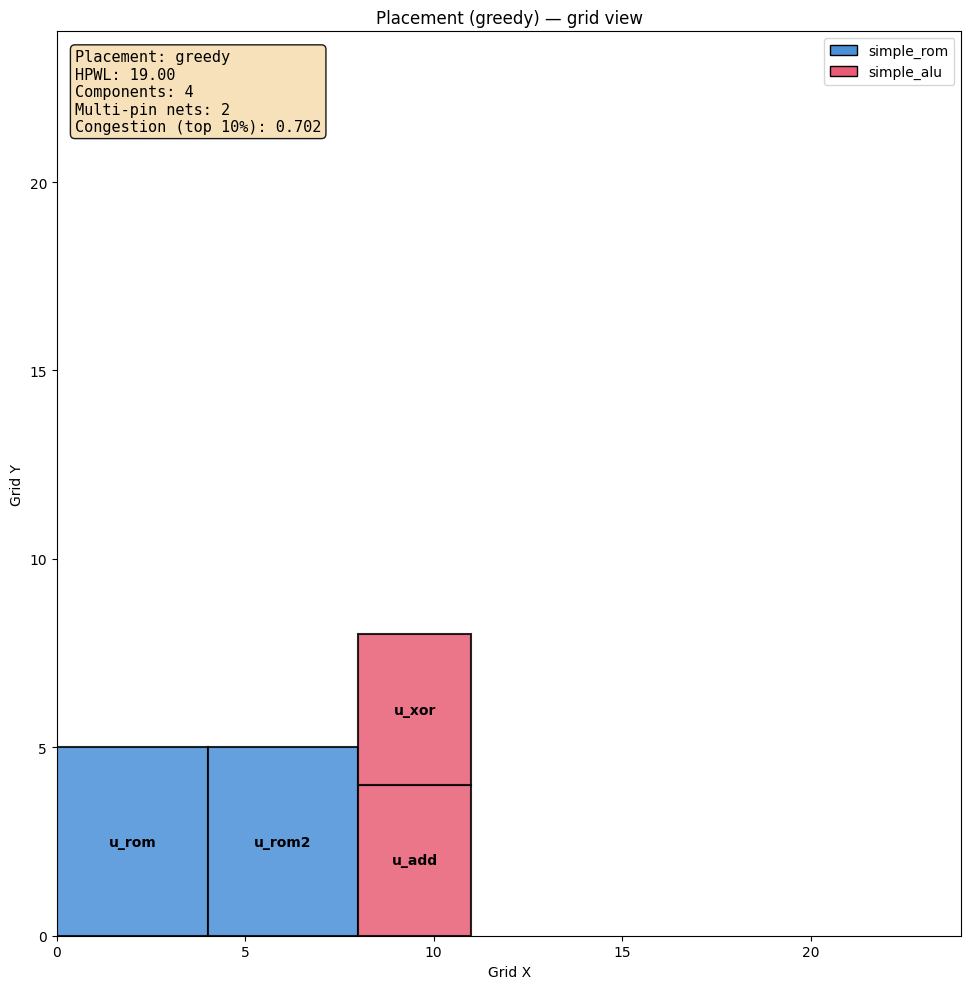

In [19]:
# =========================
# Graphical representation of PPO placement + HPWL & stats
# =========================
# Draws the placement grid with macros as colored rectangles; shows HPWL and metrics in a text box.

import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

with open("placement_results.json", "r") as f:
    data = json.load(f)

placements = dict(data.get("placements_ppo") or data.get("placements_greedy", {}))
label = "ppo" if data.get("placements_ppo") else "greedy"
instances = {i["name"]: i["type"] for i in data.get("instances", [])}
nets_data = data.get("nets") or {}
H, W = data["grid"]["H"], data["grid"]["W"]

def rect_center(y, x, h, w):
    return (y + h / 2.0, x + w / 2.0)

def hpwl_from_placements_and_nets(plc, nets):
    total = 0.0
    for net_name, pins in nets.items():
        pts = []
        for p in pins:
            if isinstance(p, dict) and p.get("inst") in plc:
                y, x, h, w = plc[p["inst"]]
                pts.append(rect_center(y, x, h, w))
        if len(pts) >= 2:
            ys, xs = [p[0] for p in pts], [p[1] for p in pts]
            total += (max(xs) - min(xs)) + (max(ys) - min(ys))
    return total

if not placements:
    print("No placements in placement_results.json. Run PPO eval or greedy placement first.")
else:
    hpwl = hpwl_from_placements_and_nets(placements, nets_data)
    metrics = (data.get("metrics") or {}).get(label, {})
    cong_top10 = metrics.get("congestion_top10")
    multi_pin_nets = [n for n, pins in nets_data.items() if len([p for p in pins if isinstance(p, dict) and p.get("inst") in placements]) >= 2]

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    colors = {"simple_rom": "#4A90D9", "simple_alu": "#E85D75"}
    for inst_name, (y, x, h, w) in placements.items():
        macro_type = instances.get(inst_name, "other")
        color = colors.get(macro_type, "#888888")
        rect = mpatches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="black", facecolor=color, alpha=0.85)
        ax.add_patch(rect)
        ax.text(x + w / 2, y + h / 2, inst_name, ha="center", va="center", fontsize=10, fontweight="bold")

    stats_lines = [
        f"Placement: {label}",
        f"HPWL: {hpwl:.2f}",
        f"Components: {len(placements)}",
        f"Multi-pin nets: {len(multi_pin_nets)}",
    ]
    if cong_top10 is not None:
        stats_lines.append(f"Congestion (top 10%): {cong_top10:.3f}")
    stats_text = "\n".join(stats_lines)
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.9), family="monospace")

    ax.set_xlabel("Grid X")
    ax.set_ylabel("Grid Y")
    ax.set_title(f"Placement ({label}) — grid view")
    legend = [mpatches.Patch(facecolor=colors["simple_rom"], edgecolor="black", label="simple_rom"),
              mpatches.Patch(facecolor=colors["simple_alu"], edgecolor="black", label="simple_alu")]
    ax.legend(handles=legend, loc="upper right")
    plt.tight_layout()
    plt.show()

In [20]:
# Spacing-aware placement and thermal helper functions
import json
import math
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    from scipy.ndimage import convolve1d
except ImportError:
    convolve1d = None

DBU = 100
GRID_CELL_MICRONS = 50
DEF_SCALE = DBU * GRID_CELL_MICRONS
CHANNEL_PADDING = 2
POWER_TABLE = {
    'simple_rom': 1.2,
    'simple_alu': 1.8,
}
LAM_HPWL = 0.6
LAM_CONG = 0.4
LAM_THERMAL = 2.5
LAM_SPACING = 1.0
THERMAL_ALPHA_WIRE = 0.5
PROXIMITY_WEIGHT = 3.0
HOTSPOT_WEIGHT = 1.5
WIRE_HEAT_WEIGHT = 0.5
FALLOFF_EXP = 1.5
THERMAL_SAFE_DISTANCE = 8.0
MAX_CONG_REF = 1.0
MAX_THERMAL_REF = 5.0

def load_results_json(path='placement_results.json'):
    with open(path, 'r') as f:
        return json.load(f)

def get_instance_records():
    if 'instances_list' in globals() and instances_list:
        return instances_list
    return load_results_json()['instances']

def get_nets_dict():
    if 'nets_dict' in globals() and nets_dict:
        return nets_dict
    return load_results_json()['nets']

def get_size_table():
    if 'sizes' in globals() and sizes:
        return {name: tuple(box) for name, box in sizes.items()}
    data = load_results_json()
    return {name: tuple(box) for name, box in data['sizes'].items()}

def get_instance_type_map(records=None):
    records = records or get_instance_records()
    return {item['name']: item['type'] for item in records}

def normalize_box(box):
    if not isinstance(box, (list, tuple)) or len(box) != 4:
        raise ValueError(f'Expected (y, x, h, w) box, got {box!r}.')
    return tuple(int(v) for v in box)

def rects_overlap(rect1, rect2):
    y1, x1, h1, w1 = normalize_box(rect1)
    y2, x2, h2, w2 = normalize_box(rect2)
    return not (y1 + h1 <= y2 or y2 + h2 <= y1 or x1 + w1 <= x2 or x2 + w2 <= x1)

def overlap_area(rect1, rect2):
    if not rects_overlap(rect1, rect2):
        return 0
    y1, x1, h1, w1 = normalize_box(rect1)
    y2, x2, h2, w2 = normalize_box(rect2)
    y_overlap = min(y1 + h1, y2 + h2) - max(y1, y2)
    x_overlap = min(x1 + w1, x2 + w2) - max(x1, x2)
    return max(0, y_overlap) * max(0, x_overlap)

def pad_rect(rect, padding, H=None, W=None):
    y, x, h, w = normalize_box(rect)
    y0 = y - padding
    x0 = x - padding
    y1 = y + h + padding
    x1 = x + w + padding
    if H is not None:
        y0 = max(0, y0)
        y1 = min(H, y1)
    if W is not None:
        x0 = max(0, x0)
        x1 = min(W, x1)
    return (y0, x0, max(0, y1 - y0), max(0, x1 - x0))

def is_legal_with_padding(y, x, h, w, occupied_or_placements, padding, H, W, ignore=None):
    if y < 0 or x < 0 or y + h > H or x + w > W:
        return False
    candidate = pad_rect((y, x, h, w), padding, H, W)
    items = occupied_or_placements.items() if isinstance(occupied_or_placements, dict) else occupied_or_placements
    for item in items:
        name, other_box = item
        if ignore is not None and name == ignore:
            continue
        other = pad_rect(other_box, padding, H, W)
        if rects_overlap(candidate, other):
            return False
    return True

def validate_placement_geometry(plc, H, W, padding=0):
    errors = []
    normalized = {name: normalize_box(box) for name, box in plc.items()}
    for name, (y, x, h, w) in normalized.items():
        if y < 0 or x < 0 or h <= 0 or w <= 0:
            errors.append(f'{name}: invalid box (y={y}, x={x}, h={h}, w={w}).')
        if y + h > H or x + w > W:
            errors.append(f'{name}: box exceeds grid bounds (H={H}, W={W}).')
    rows = list(normalized.items())
    for i, (name_a, rect_a) in enumerate(rows):
        for name_b, rect_b in rows[i + 1:]:
            if rects_overlap(rect_a, rect_b):
                errors.append(f'Actual macro overlap between {name_a} and {name_b}.')
            if padding > 0 and rects_overlap(pad_rect(rect_a, padding, H, W), pad_rect(rect_b, padding, H, W)):
                errors.append(f'Halo overlap between {name_a} and {name_b} with padding={padding}.')
    return errors

def compute_spacing_penalty(plc, padding, H, W):
    if padding <= 0:
        return 0.0, []
    penalty = 0.0
    violations = []
    rows = list(plc.items())
    for i, (name_a, rect_a) in enumerate(rows):
        padded_a = pad_rect(rect_a, padding, H, W)
        for name_b, rect_b in rows[i + 1:]:
            padded_b = pad_rect(rect_b, padding, H, W)
            area = overlap_area(padded_a, padded_b)
            if area > 0:
                penalty += area
                violations.append((name_a, name_b, area))
    return float(penalty), violations

def build_net_to_points(plc, nets, G_src):
    net_to_points = {}
    for net in nets:
        pts = []
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get('type') == 'instance' and nbr in plc:
                y, x, h, w = plc[nbr]
                pts.append((y + h / 2.0, x + w / 2.0))
        if pts:
            net_to_points[net] = pts
    return net_to_points

def smooth_heatmap(grid):
    grid = np.asarray(grid, dtype=float)
    if convolve1d is None:
        return grid
    smooth = convolve1d(grid, np.ones(5) / 5.0, axis=0, mode='nearest')
    smooth = convolve1d(smooth, np.ones(5) / 5.0, axis=1, mode='nearest')
    return smooth

def compute_congestion_proxy(plc, H, W, nets, G_src, smooth=True):
    if 'compute_congestion' in globals():
        congestion_map = compute_congestion(plc, H, W, nets, G_src)
    else:
        congestion_map = np.zeros((H, W), dtype=float)
        centers = build_net_to_points(plc, nets, G_src)
        for pts in centers.values():
            if len(pts) < 2:
                continue
            y0, x0 = [int(round(v)) for v in pts[0]]
            for y1, x1 in pts[1:]:
                y1 = int(round(y1))
                x1 = int(round(x1))
                xlo, xhi = sorted((x0, x1))
                ylo, yhi = sorted((y0, y1))
                congestion_map[y0, xlo:xhi + 1] += 1
                congestion_map[ylo:yhi + 1, x1] += 1
    if smooth:
        congestion_map = smooth_heatmap(congestion_map)
    if 'congestion_score' in globals():
        congestion_value = float(congestion_score(congestion_map))
    else:
        flat = congestion_map.flatten()
        k = max(1, int(np.ceil(0.10 * flat.size)))
        congestion_value = float(np.mean(np.sort(flat)[-k:]))
    return congestion_value, np.asarray(congestion_map, dtype=float)

def normalize_reward_terms(hpwl, congestion_value, thermal_score, H, W, max_cong_ref=MAX_CONG_REF, max_thermal_ref=MAX_THERMAL_REF):
    hpwl_norm = float(hpwl) / max(1.0, H + W)
    cong_norm = float(congestion_value) / max(1.0, max_cong_ref)
    thermal_norm = float(thermal_score) / max(1.0, max_thermal_ref)
    return hpwl_norm, cong_norm, thermal_norm, {
        'hpwl_scale': max(1.0, H + W),
        'congestion_scale': max(1.0, max_cong_ref),
        'thermal_scale': max(1.0, max_thermal_ref),
    }

def compute_thermal_score(placements, instances, H, W, congestion_map=None, power_table=None, alpha_wire=WIRE_HEAT_WEIGHT, proximity_weight=PROXIMITY_WEIGHT, hotspot_weight=HOTSPOT_WEIGHT, falloff_exp=FALLOFF_EXP, thermal_safe_distance=THERMAL_SAFE_DISTANCE):
    power_table = power_table or POWER_TABLE
    inst_to_type = instances if isinstance(instances, dict) else get_instance_type_map(instances)
    thermal_map = np.zeros((H, W), dtype=float)
    yy, xx = np.indices((H, W))
    for inst_name, box in placements.items():
        y, x, h, w = normalize_box(box)
        center_y = y + h / 2.0
        center_x = x + w / 2.0
        macro_type = inst_to_type[inst_name]
        power = float(power_table.get(macro_type, 1.0))
        dist = np.sqrt((yy - center_y) ** 2 + (xx - center_x) ** 2)
        thermal_map += power / ((dist + 1.0) ** falloff_exp)
    if congestion_map is not None:
        thermal_map += alpha_wire * np.asarray(congestion_map, dtype=float)
    flat = thermal_map.flatten()
    k = max(1, int(np.ceil(0.10 * flat.size)))
    thermal_hotspot = float(np.mean(np.sort(flat)[-k:]))
    proximity_penalty = 0.0
    rows = list(placements.items())
    for i, (name_a, rect_a) in enumerate(rows):
        y_a, x_a, h_a, w_a = normalize_box(rect_a)
        cy_a = y_a + h_a / 2.0
        cx_a = x_a + w_a / 2.0
        power_a = float(power_table.get(inst_to_type[name_a], 1.0))
        for name_b, rect_b in rows[i + 1:]:
            y_b, x_b, h_b, w_b = normalize_box(rect_b)
            cy_b = y_b + h_b / 2.0
            cx_b = x_b + w_b / 2.0
            power_b = float(power_table.get(inst_to_type[name_b], 1.0))
            dist = math.sqrt((cy_a - cy_b) ** 2 + (cx_a - cx_b) ** 2)
            pair_penalty = (power_a * power_b) / (dist + 1.0)
            if dist < thermal_safe_distance:
                pair_penalty += ((thermal_safe_distance - dist) / thermal_safe_distance) * power_a * power_b
            proximity_penalty += pair_penalty
    thermal_score = float(hotspot_weight * thermal_hotspot + proximity_weight * proximity_penalty)
    return thermal_score, thermal_map

def thermal_map_stats(thermal_map):
    flat = np.asarray(thermal_map, dtype=float).flatten()
    if flat.size == 0:
        return 0.0, 0.0
    k = max(1, int(np.ceil(0.10 * flat.size)))
    return float(np.max(flat)), float(np.mean(np.sort(flat)[-k:]))

def evaluate_method(method_name, plc, instances, nets, G_src, H, W, channel_padding=CHANNEL_PADDING, power_table=POWER_TABLE, alpha_wire=THERMAL_ALPHA_WIRE):
    if plc is None:
        return {'method': method_name, 'available': False}
    normalized = {name: normalize_box(box) for name, box in plc.items()}
    geometry_errors = validate_placement_geometry(normalized, H, W, padding=0)
    spacing_errors = validate_placement_geometry(normalized, H, W, padding=channel_padding)
    spacing_penalty, spacing_violations = compute_spacing_penalty(normalized, channel_padding, H, W)
    hpwl = float(hpwl_total_from_placements(normalized, nets, G_src))
    congestion_value, congestion_map = compute_congestion_proxy(normalized, H, W, nets, G_src)
    thermal_value, thermal_map = compute_thermal_score(normalized, instances, H, W, congestion_map, power_table, alpha_wire)
    max_temp, top10_temp = thermal_map_stats(thermal_map)
    return {
        'method': method_name,
        'available': True,
        'placements': {name: list(box) for name, box in normalized.items()},
        'hpwl': hpwl,
        'congestion': float(congestion_value),
        'thermal_score': float(thermal_value),
        'max_temp': float(max_temp),
        'top10_temp': float(top10_temp),
        'spacing_penalty': float(spacing_penalty),
        'legal_spacing_pass': len(spacing_errors) == 0,
        'geometry_pass': len(geometry_errors) == 0,
        'spacing_violations': spacing_violations,
        'errors': spacing_errors,
        'congestion_map': congestion_map,
        'thermal_map': thermal_map,
    }

def draw_placement_layout(ax, placements, instance_type_map, H, W, title):
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_aspect('equal')
    colors = {'simple_rom': '#4A90D9', 'simple_alu': '#E85D75'}
    for inst_name, box in placements.items():
        y, x, h, w = normalize_box(box)
        macro_type = instance_type_map.get(inst_name, 'other')
        rect = mpatches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='black', facecolor=colors.get(macro_type, '#888888'), alpha=0.85)
        ax.add_patch(rect)
        ax.text(x + w / 2.0, y + h / 2.0, inst_name, ha='center', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('Grid X')
    ax.set_ylabel('Grid Y')

def draw_heatmap(ax, heatmap, title, cmap, vmin=None, vmax=None):
    im = ax.imshow(np.asarray(heatmap, dtype=float), origin='upper', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def plot_method_summary(result, instance_type_map, H, W, congestion_limits=None, thermal_limits=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    draw_placement_layout(axes[0], result['placements'], instance_type_map, H, W, f"{result['method']} placement")
    congestion_vmin, congestion_vmax = congestion_limits if congestion_limits is not None else (None, None)
    thermal_vmin, thermal_vmax = thermal_limits if thermal_limits is not None else (None, None)
    draw_heatmap(axes[1], result['congestion_map'], f"{result['method']} congestion", 'viridis', vmin=congestion_vmin, vmax=congestion_vmax)
    draw_heatmap(axes[2], result['thermal_map'], f"{result['method']} thermal", 'magma', vmin=thermal_vmin, vmax=thermal_vmax)
    plt.tight_layout()
    plt.show()

def print_comparison_table(results_by_method):
    headers = ('Method', 'HPWL', 'Congestion', 'Thermal Score', 'Max Temp', 'Mean Top10 Temp', 'Spacing Pass')
    print(f"{headers[0]:<16} | {headers[1]:>8} | {headers[2]:>10} | {headers[3]:>13} | {headers[4]:>8} | {headers[5]:>15} | {headers[6]:>12}")
    print('-' * 100)
    for method in ('Random', 'Greedy', 'PPO', 'Thermal-PPO-v1', 'Thermal-PPO-v2'):
        result = results_by_method.get(method)
        if not result or not result.get('available'):
            print(f"{method:<16} | {'n/a':>8} | {'n/a':>10} | {'n/a':>13} | {'n/a':>8} | {'n/a':>15} | {'n/a':>12}")
            continue
        legal_text = 'yes' if result['legal_spacing_pass'] else 'no'
        print(f"{method:<16} | {result['hpwl']:>8.2f} | {result['congestion']:>10.3f} | {result['thermal_score']:>13.3f} | {result['max_temp']:>8.3f} | {result['top10_temp']:>15.3f} | {legal_text:>12}")


In [21]:
# Spacing-aware random and greedy baselines, plus PPO reevaluation
instance_records_eval = get_instance_records()
instance_type_map_eval = get_instance_type_map(instance_records_eval)
nets_eval = get_nets_dict()
size_table_eval = get_size_table()
instance_names_eval = [item['name'] for item in instance_records_eval]

def random_place_with_padding(inst_names, size_table, H, W, padding, seed=7, max_tries=5000):
    rng_local = np.random.default_rng(seed)
    placements_local = {}
    for inst_name in inst_names:
        h, w = size_table[inst_name]
        placed = False
        for _ in range(max_tries):
            y = int(rng_local.integers(0, H - h + 1))
            x = int(rng_local.integers(0, W - w + 1))
            if is_legal_with_padding(y, x, h, w, placements_local, padding, H, W):
                placements_local[inst_name] = (y, x, h, w)
                placed = True
                break
        if not placed:
            raise RuntimeError(f'Could not place {inst_name!r} with channel padding={padding}.')
    return placements_local

def greedy_place_with_padding(inst_names, size_table, nets, G_src, H, W, padding, sample_step=1):
    inst_to_nets = {inst_name: [] for inst_name in inst_names}
    for net in nets:
        for nbr in G_src.neighbors(net):
            if G_src.nodes[nbr].get('type') == 'instance':
                inst_to_nets[nbr].append(net)
    order = sorted(inst_names, key=lambda inst_name: (size_table[inst_name][0] * size_table[inst_name][1], len(inst_to_nets[inst_name])), reverse=True)
    placements_local = {}
    for inst_name in order:
        h, w = size_table[inst_name]
        best = None
        for y in range(0, H - h + 1, sample_step):
            for x in range(0, W - w + 1, sample_step):
                if not is_legal_with_padding(y, x, h, w, placements_local, padding, H, W):
                    continue
                trial = dict(placements_local)
                trial[inst_name] = (y, x, h, w)
                inc_hpwl = 0.0
                for net in inst_to_nets[inst_name]:
                    points = []
                    for nbr in G_src.neighbors(net):
                        if G_src.nodes[nbr].get('type') != 'instance':
                            continue
                        if nbr == inst_name:
                            points.append((y + h / 2.0, x + w / 2.0))
                        elif nbr in placements_local:
                            y2, x2, h2, w2 = placements_local[nbr]
                            points.append((y2 + h2 / 2.0, x2 + w2 / 2.0))
                    inc_hpwl += hpwl_points(points)
                if best is None or inc_hpwl < best[0]:
                    best = (inc_hpwl, y, x)
        if best is None:
            raise RuntimeError(f'Greedy placer could not place {inst_name!r} with channel padding={padding}.')
        _, y_best, x_best = best
        placements_local[inst_name] = (y_best, x_best, h, w)
    return placements_local

placements_random_spaced = random_place_with_padding(instance_names_eval, size_table_eval, H, W, CHANNEL_PADDING, seed=7)
placements_greedy_spaced = greedy_place_with_padding(instance_names_eval, size_table_eval, nets_eval, G_src, H, W, CHANNEL_PADDING, sample_step=1)

ppo_source = None
if 'ppo_placements' in globals() and ppo_placements:
    ppo_source = {name: tuple(box) for name, box in ppo_placements.items()}
else:
    ppo_json = load_results_json().get('placements_ppo')
    if ppo_json:
        ppo_source = {name: tuple(box) for name, box in ppo_json.items()}

placement_evaluations = {}
placement_evaluations['Random'] = evaluate_method('Random', placements_random_spaced, instance_records_eval, nets, G_src, H, W)
placement_evaluations['Greedy'] = evaluate_method('Greedy', placements_greedy_spaced, instance_records_eval, nets, G_src, H, W)
placement_evaluations['PPO'] = evaluate_method('PPO', ppo_source, instance_records_eval, nets, G_src, H, W) if ppo_source else {'method': 'PPO', 'available': False}

random_metrics = placement_evaluations['Random']
greedy_metrics = placement_evaluations['Greedy']
ppo_metrics = placement_evaluations['PPO']

print('Spacing-aware baseline placements computed with CHANNEL_PADDING =', CHANNEL_PADDING)
for method_name in ('Random', 'Greedy', 'PPO'):
    result = placement_evaluations.get(method_name, {})
    if not result.get('available'):
        print(f'{method_name}: unavailable')
        continue
    print(f"{method_name}: HPWL={result['hpwl']:.2f}, Congestion={result['congestion']:.3f}, Thermal={result['thermal_score']:.3f}, Legal={result['legal_spacing_pass']}")
    if result['errors']:
        print('  spacing issues:')
        for message in result['errors']:
            print('   -', message)


Spacing-aware baseline placements computed with CHANNEL_PADDING = 2
Random: HPWL=60.50, Congestion=0.559, Thermal=3.605, Legal=True
Greedy: HPWL=39.00, Congestion=0.779, Thermal=5.379, Legal=True
PPO: unavailable


In [22]:
"""Legacy thermal PPO cell retained for notebook history.
import gymnasium as gym
from gymnasium import spaces
import torch
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

THERMAL_PPO_TIMESTEPS = 20000
THERMAL_MODEL_PATH = 'models/ppo_thermal_placement.zip'

class ThermalPlacementEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(self, instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.5, lam_thermal=1.0, lam_spacing=1.0, channel_padding=1, alpha_wire=0.3, power_table=None, seed=42):
        super().__init__()
        self.instances = list(instances)
        self.nets = list(nets)
        self.sizes = {name: tuple(box) for name, box in sizes.items()}
        self.inst_type_map = get_instance_type_map(get_instance_records())
        deg = {inst_name: sum(1 for nbr in G_src.neighbors(inst_name) if G_src.nodes[nbr].get('type') == 'net') for inst_name in self.instances}
        self.order = sorted(self.instances, key=lambda inst_name: (self.sizes[inst_name][0] * self.sizes[inst_name][1], deg[inst_name]), reverse=True)
        self.deg = deg
        self.G_src = G_src
        self.H = H
        self.W = W
        self.lam_cong = lam_cong
        self.lam_thermal = lam_thermal
        self.lam_spacing = lam_spacing
        self.channel_padding = channel_padding
        self.alpha_wire = alpha_wire
        self.power_table = power_table or POWER_TABLE
        self.max_steps = max(len(self.order) * self.H * self.W, len(self.order) * 20)
        self.rng = np.random.default_rng(seed)
        self.action_space = spaces.Discrete(self.H * self.W)
        self.observation_space = spaces.Dict({
            'canvas': spaces.Box(0, 1, shape=(self.H, self.W), dtype=np.uint8),
            'cur': spaces.Box(low=0.0, high=1.0, shape=(5,), dtype=np.float32),
        })
        self.reset(seed=seed)

    def _legal(self, y, x, h, w):
        return is_legal_with_padding(y, x, h, w, self.placements, self.channel_padding, self.H, self.W)

    def _mask(self):
        mask = np.zeros(self.H * self.W, dtype=bool)
        if self.idx >= len(self.order):
            return mask
        inst_name = self.order[self.idx]
        h, w = self.sizes[inst_name]
        for y in range(self.H - h + 1):
            base = y * self.W
            for x in range(self.W - w + 1):
                if self._legal(y, x, h, w):
                    mask[base + x] = True
        return mask

    def _obs(self):
        max_deg = max(1, max(self.deg.values()))
        if self.idx < len(self.order):
            inst_name = self.order[self.idx]
            h, w = self.sizes[inst_name]
            power = float(self.power_table.get(self.inst_type_map[inst_name], 1.0))
            max_power = max(max(self.power_table.values()), 1.0)
            cur = np.array([
                h / self.H,
                w / self.W,
                self.deg[inst_name] / max_deg,
                self.idx / max(1, len(self.order) - 1),
                power / max_power,
            ], dtype=np.float32)
        else:
            cur = np.zeros(5, dtype=np.float32)
        return {'canvas': self.occ.copy(), 'cur': cur}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.occ = np.zeros((self.H, self.W), dtype=np.uint8)
        self.idx = 0
        self.step_count = 0
        self.placements = {}
        obs = self._obs()
        return obs, {'action_mask': self._mask()}

    def step(self, action):
        if not self.action_space.contains(action):
            raise ValueError(f'Action {action!r} is outside the discrete action space.')
        self.step_count += 1
        if self.idx >= len(self.order):
            return self._obs(), 0.0, True, False, {'action_mask': self._mask()}
        inst_name = self.order[self.idx]
        h, w = self.sizes[inst_name]
        y, x = divmod(int(action), self.W)
        legal_mask = self._mask()
        if not legal_mask.any():
            return self._obs(), -1e3, False, True, {'action_mask': legal_mask, 'no_legal_moves': True}
        if not self._legal(y, x, h, w):
            truncated = self.step_count >= self.max_steps
            return self._obs(), -(0.1 + self.lam_spacing), False, truncated, {'action_mask': legal_mask, 'illegal': True}
        self.occ[y:y + h, x:x + w] = 1
        self.placements[inst_name] = (y, x, h, w)
        self.idx += 1
        done = False
        truncated = self.step_count >= self.max_steps and self.idx < len(self.order)
        reward = 0.0
        info = {'action_mask': self._mask()}
        if self.idx >= len(self.order):
            done = True
            hpwl = float(hpwl_total_from_placements(self.placements, self.nets, self.G_src))
            congestion_value, congestion_map = compute_congestion_proxy(self.placements, self.H, self.W, self.nets, self.G_src)
            spacing_penalty, _ = compute_spacing_penalty(self.placements, self.channel_padding, self.H, self.W)
            thermal_value, thermal_map = compute_thermal_score(self.placements, self.inst_type_map, self.H, self.W, congestion_map, self.power_table, self.alpha_wire)
            reward = -(hpwl + self.lam_cong * congestion_value + self.lam_thermal * thermal_value + self.lam_spacing * spacing_penalty)
            info.update({
                'hpwl': hpwl,
                'congestion': congestion_value,
                'thermal_score': thermal_value,
                'spacing_penalty': spacing_penalty,
                'congestion_map': congestion_map,
                'thermal_map': thermal_map,
            })
        return self._obs(), reward, done, truncated, info

def thermal_mask_fn(env):
    return env.unwrapped._mask()

thermal_base_env = ThermalPlacementEnv(instance_names_eval, nets, size_table_eval, G_src, H=H, W=W, lam_cong=LAM_CONG, lam_thermal=LAM_THERMAL, lam_spacing=LAM_SPACING, channel_padding=CHANNEL_PADDING, alpha_wire=THERMAL_ALPHA_WIRE, power_table=POWER_TABLE, seed=42)
thermal_env = ActionMasker(thermal_base_env, thermal_mask_fn)
thermal_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Thermal-PPO device: {thermal_device}')

thermal_model = MaskablePPO(
    'MultiInputPolicy',
    thermal_env,
    device=thermal_device,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    clip_range=0.2,
    seed=42,
)

thermal_model.learn(total_timesteps=THERMAL_PPO_TIMESTEPS)
os.makedirs('models', exist_ok=True)
thermal_model.save(THERMAL_MODEL_PATH)
print('Saved thermal PPO model to', THERMAL_MODEL_PATH)

obs, info = thermal_env.reset()
done = False
truncated = False
for _ in range(thermal_base_env.max_steps + 5):
    action, _ = thermal_model.predict(obs, deterministic=True, action_masks=info.get('action_mask'))
    action = int(np.squeeze(action))
    obs, reward, done, truncated, info = thermal_env.step(action)
    if done or truncated:
        break
if not (done or truncated):
    raise RuntimeError('Thermal-PPO evaluation did not terminate within the safety step cap.')
if truncated and thermal_env.unwrapped.idx < len(thermal_env.unwrapped.order):
    raise RuntimeError('Thermal-PPO evaluation truncated before placing all macros. Check action mask legality and reward setup.')

thermal_ppo_placements = {name: tuple(box) for name, box in thermal_env.unwrapped.placements.items()}
thermal_ppo_metrics = evaluate_method('Thermal-PPO', thermal_ppo_placements, instance_records_eval, nets, G_src, H, W)
placement_evaluations['Thermal-PPO'] = thermal_ppo_metrics
"""
import os
import numpy as np
import torch
import gymnasium as gym
from gymnasium import spaces
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

TIMESTEPS_THERMAL = 100_000
THERMAL_MODEL_PATH = 'models/thermal_ppo_placement.zip'

class PlacementEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(self, instances, nets, sizes, G_src, H=24, W=24, lam_cong=0.5, lam_thermal=1.0, channel_padding=1, alpha_wire=0.3, power_table=None, seed=42):
        super().__init__()
        self.instances = list(instances)
        self.nets = list(nets)
        self.sizes = {name: tuple(box) for name, box in sizes.items()}
        self.inst_type_map = get_instance_type_map(get_instance_records())
        self.G_src = G_src
        self.H = H
        self.W = W
        self.lam_cong = float(lam_cong)
        self.lam_thermal = float(lam_thermal)
        self.channel_padding = int(channel_padding)
        self.alpha_wire = float(alpha_wire)
        self.power_table = dict(power_table or POWER_TABLE)
        self.deg = {
            inst_name: sum(1 for nbr in G_src.neighbors(inst_name) if G_src.nodes[nbr].get('type') == 'net')
            for inst_name in self.instances
        }
        self.order = sorted(
            self.instances,
            key=lambda inst_name: (self.sizes[inst_name][0] * self.sizes[inst_name][1], self.deg[inst_name]),
            reverse=True,
        )
        self.action_space = spaces.Discrete(self.H * self.W)
        self.observation_space = spaces.Dict({
            'canvas': spaces.Box(0, 1, shape=(self.H, self.W), dtype=np.uint8),
            'cur': spaces.Box(low=0.0, high=1.0, shape=(5,), dtype=np.float32),
        })
        self.rng = np.random.default_rng(seed)
        self.reset(seed=seed)

    def _legal(self, y, x, h, w):
        return is_legal_with_padding(y, x, h, w, self.placements, self.channel_padding, self.H, self.W)

    def _mask(self):
        mask = np.zeros(self.H * self.W, dtype=bool)
        if self.idx >= len(self.order):
            return mask
        inst_name = self.order[self.idx]
        h, w = self.sizes[inst_name]
        for y in range(self.H - h + 1):
            row = y * self.W
            for x in range(self.W - w + 1):
                if self._legal(y, x, h, w):
                    mask[row + x] = True
        return mask

    def _obs(self):
        max_deg = max(1, max(self.deg.values()))
        max_power = max(max(self.power_table.values()), 1.0)
        if self.idx < len(self.order):
            inst_name = self.order[self.idx]
            h, w = self.sizes[inst_name]
            power = float(self.power_table.get(self.inst_type_map[inst_name], 1.0))
            cur = np.array([
                h / self.H,
                w / self.W,
                self.deg[inst_name] / max_deg,
                self.idx / max(1, len(self.order) - 1),
                power / max_power,
            ], dtype=np.float32)
        else:
            cur = np.zeros(5, dtype=np.float32)
        return {'canvas': self.occ.copy(), 'cur': cur}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.occ = np.zeros((self.H, self.W), dtype=np.uint8)
        self.idx = 0
        self.placements = {}
        obs = self._obs()
        info = {'action_mask': self._mask()}
        if self.idx < len(self.order) and not info['action_mask'].any():
            raise RuntimeError('No legal actions are available at reset. Check macro sizes, grid size, or CHANNEL_PADDING.')
        return obs, info

    def step(self, action):
        if not self.action_space.contains(action):
            raise ValueError(f'Action {action!r} is outside the discrete action space.')
        if self.idx >= len(self.order):
            return self._obs(), 0.0, True, False, {'action_mask': self._mask()}

        legal_mask = self._mask()
        if not legal_mask.any():
            raise RuntimeError('No legal actions remain before all macros were placed. Check PlacementEnv.step() legality and CHANNEL_PADDING.')

        inst_name = self.order[self.idx]
        h, w = self.sizes[inst_name]
        y, x = divmod(int(action), self.W)
        if not self._legal(y, x, h, w):
            return self._obs(), -0.1, False, False, {'action_mask': legal_mask, 'illegal': True}

        self.occ[y:y + h, x:x + w] = 1
        self.placements[inst_name] = (y, x, h, w)
        self.idx += 1

        terminated = self.idx >= len(self.order)
        truncated = False
        reward = 0.0
        obs = self._obs()

        if terminated:
            hpwl = float(hpwl_total_from_placements(self.placements, self.nets, self.G_src))
            congestion_value, congestion_map = compute_congestion_proxy(self.placements, self.H, self.W, self.nets, self.G_src)
            thermal_value, thermal_map = compute_thermal_score(
                self.placements,
                self.inst_type_map,
                self.H,
                self.W,
                congestion_map=congestion_map,
                power_table=self.power_table,
                alpha_wire=self.alpha_wire,
            )
            reward = -(hpwl + self.lam_cong * congestion_value + self.lam_thermal * thermal_value)
            info = {
                'action_mask': self._mask(),
                'hpwl': hpwl,
                'congestion': congestion_value,
                'thermal_score': thermal_value,
                'congestion_map': congestion_map,
                'thermal_map': thermal_map,
            }
        else:
            next_mask = self._mask()
            if not next_mask.any():
                raise RuntimeError('No legal actions remain before the episode completed. Check macro padding and placement order.')
            info = {'action_mask': next_mask}

        return obs, reward, terminated, truncated, info

def thermal_mask_fn(env):
    return env.unwrapped._mask()

thermal_env = PlacementEnv(
    instances=instance_names_eval,
    nets=nets_eval,
    sizes=size_table_eval,
    G_src=G_src,
    H=H,
    W=W,
    lam_cong=0.5,
    lam_thermal=1.0,
    channel_padding=CHANNEL_PADDING,
    alpha_wire=THERMAL_ALPHA_WIRE,
    power_table=POWER_TABLE,
    seed=42,
)
thermal_env_wrapped = ActionMasker(thermal_env, thermal_mask_fn)
thermal_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Thermal-aware PPO device: {thermal_device}')

thermal_model = MaskablePPO(
    'MultiInputPolicy',
    thermal_env_wrapped,
    device=thermal_device,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    n_steps=2048,
    batch_size=256,
    ent_coef=0.01,
    clip_range=0.2,
    seed=42,
)

thermal_model.learn(total_timesteps=TIMESTEPS_THERMAL)
os.makedirs('models', exist_ok=True)
thermal_model.save(THERMAL_MODEL_PATH)
print('Saved thermal-aware PPO model to', THERMAL_MODEL_PATH)

env_vis = ActionMasker(
    PlacementEnv(
        instances=instance_names_eval,
        nets=nets_eval,
        sizes=size_table_eval,
        G_src=G_src,
        H=H,
        W=W,
        lam_cong=0.5,
        lam_thermal=1.0,
        channel_padding=CHANNEL_PADDING,
        alpha_wire=THERMAL_ALPHA_WIRE,
        power_table=POWER_TABLE,
        seed=42,
    ),
    thermal_mask_fn,
)

obs, info = env_vis.reset()
max_steps = len(instance_names_eval) + 5

for step in range(max_steps):
    mask = info.get('action_mask')
    if mask is not None and not np.any(mask) and env_vis.unwrapped.idx < len(env_vis.unwrapped.order):
        raise RuntimeError('Evaluation rollout found no legal actions before all macros were placed.')
    action, _ = thermal_model.predict(
        obs,
        action_masks=mask,
        deterministic=True,
    )
    obs, reward, done, trunc, info = env_vis.step(int(np.squeeze(action)))
    if done or trunc:
        break
else:
    raise RuntimeError('Evaluation rollout did not terminate. Check PlacementEnv.step() termination logic.')

if trunc:
    raise RuntimeError('Thermal-aware PPO evaluation truncated unexpectedly.')

placements_thermal_ppo = {name: list(box) for name, box in env_vis.unwrapped.placements.items()}
thermal_ppo_placements = placements_thermal_ppo
thermal_ppo_metrics = evaluate_method('Thermal-PPO', placements_thermal_ppo, instance_records_eval, nets_eval, G_src, H, W)
placement_evaluations['Thermal-PPO'] = thermal_ppo_metrics
print(f"Thermal-PPO: HPWL={thermal_ppo_metrics['hpwl']:.2f}, Congestion={thermal_ppo_metrics['congestion']:.3f}, Thermal={thermal_ppo_metrics['thermal_score']:.3f}, Legal={thermal_ppo_metrics['legal_spacing_pass']}")


Thermal-aware PPO device: cpu
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4        |
|    ep_rew_mean     | -57.6    |
| time/              |          |
|    fps             | 140      |
|    iterations      | 1        |
|    time_elapsed    | 14       |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 4             |
|    ep_rew_mean          | -58.4         |
| time/                   |               |
|    fps                  | 133           |
|    iterations           | 2             |
|    time_elapsed         | 30            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00025621353 |
|    clip_fraction        | 0             |
|    cli

Method           |     HPWL | Congestion | Thermal Score | Max Temp | Mean Top10 Temp | Spacing Pass
----------------------------------------------------------------------------------------------------
Random           |    60.50 |      0.559 |         3.605 |    1.168 |           0.703 |          yes
Greedy           |    39.00 |      0.779 |         5.379 |    1.598 |           0.907 |          yes
PPO              |      n/a |        n/a |           n/a |      n/a |             n/a |          n/a
Thermal-PPO-v1   |      n/a |        n/a |           n/a |      n/a |             n/a |          n/a
Thermal-PPO-v2   |      n/a |        n/a |           n/a |      n/a |             n/a |          n/a


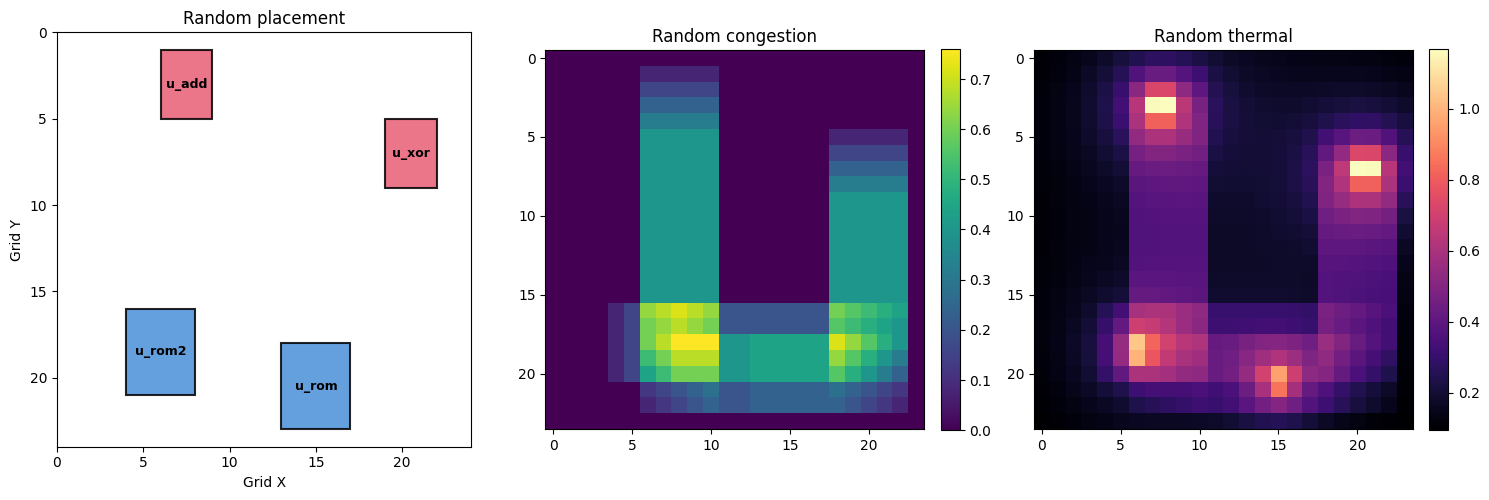

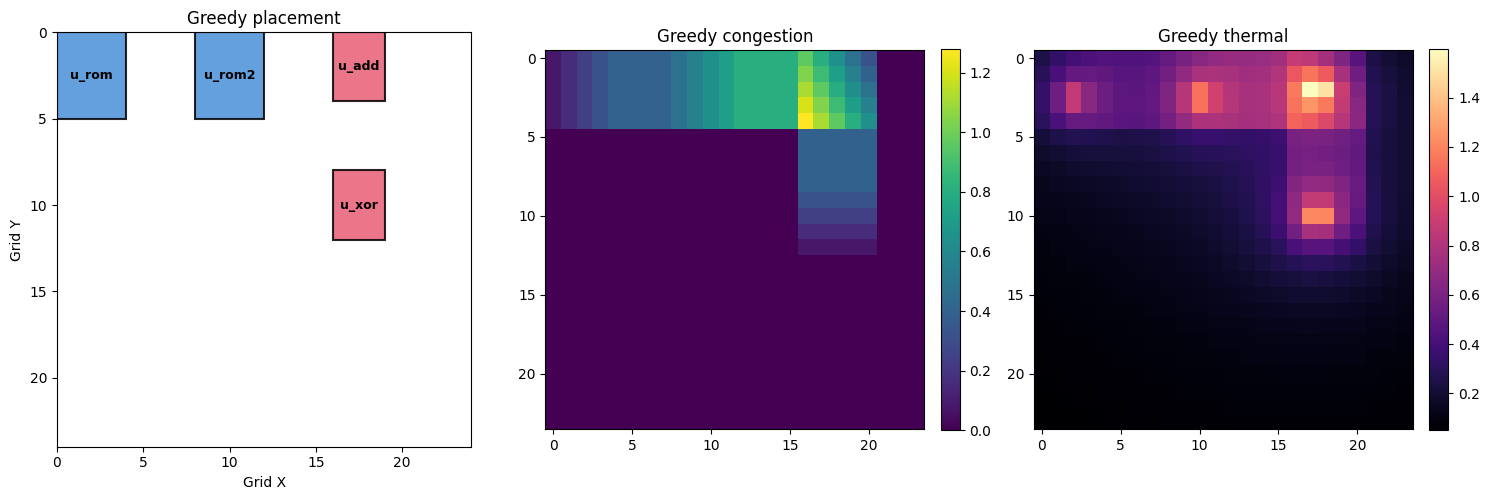

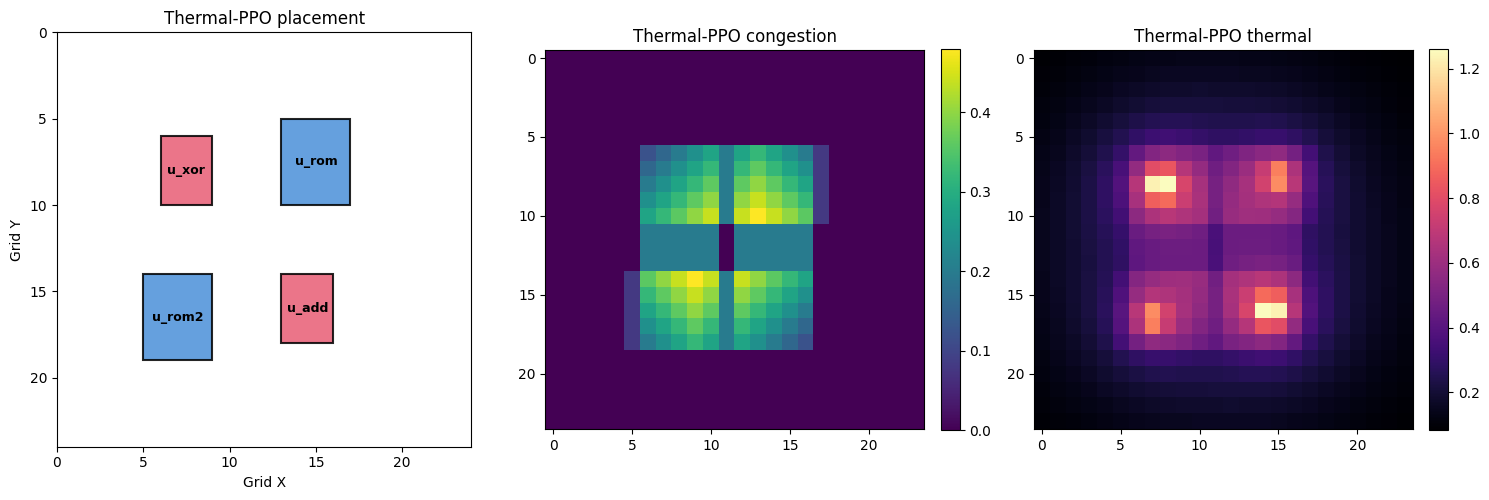

Updated placement_results.json with random_metrics, greedy_metrics, ppo_metrics, and thermal_ppo_metrics.
OpenROAD export intentionally skipped in this notebook step.


In [23]:
"""Legacy comparison/export cell retained for notebook history.
instance_records_export = get_instance_records()
instance_type_map_export = get_instance_type_map(instance_records_export)
nets_export = get_nets_dict()
size_table_export = get_size_table()

if 'placement_evaluations' not in globals():
    raise ValueError('Run the spacing-aware baseline cell before the comparison/export cell.')
if 'thermal_ppo_metrics' in globals() and thermal_ppo_metrics:
    placement_evaluations['Thermal-PPO'] = thermal_ppo_metrics

print_comparison_table(placement_evaluations)

for method_name in ('Random', 'Greedy', 'PPO', 'Thermal-PPO'):
    result = placement_evaluations.get(method_name)
    if result and result.get('available'):
        plot_method_summary(result, instance_type_map_export, H, W)

def serializable_metrics(result):
    if not result or not result.get('available'):
        return None
    return {
        'hpwl': float(result['hpwl']),
        'congestion': float(result['congestion']),
        'thermal_score': float(result['thermal_score']),
        'spacing_penalty': float(result['spacing_penalty']),
        'legal_spacing_pass': bool(result['legal_spacing_pass']),
        'geometry_pass': bool(result['geometry_pass']),
        'errors': list(result['errors']),
        'placements': result['placements'],
    }

saved_results = load_results_json()
saved_results['channel_padding'] = CHANNEL_PADDING
saved_results['power_table'] = POWER_TABLE
saved_results['random_metrics'] = serializable_metrics(placement_evaluations.get('Random'))
saved_results['greedy_metrics'] = serializable_metrics(placement_evaluations.get('Greedy'))
saved_results['ppo_metrics'] = serializable_metrics(placement_evaluations.get('PPO'))
saved_results['thermal_ppo_metrics'] = serializable_metrics(placement_evaluations.get('Thermal-PPO'))
saved_results['placements_random_spaced'] = placement_evaluations['Random']['placements']
saved_results['placements_greedy_spaced'] = placement_evaluations['Greedy']['placements']
if placement_evaluations.get('PPO', {}).get('available'):
    saved_results['placements_ppo'] = placement_evaluations['PPO']['placements']
if placement_evaluations.get('Thermal-PPO', {}).get('available'):
    saved_results['placements_thermal_ppo'] = placement_evaluations['Thermal-PPO']['placements']
with open('placement_results.json', 'w') as f:
    json.dump(saved_results, f, indent=2)
print('Updated placement_results.json with random_metrics, greedy_metrics, ppo_metrics, and thermal_ppo_metrics.')

def collect_macro_pin_defs(nets_data, placements, inst_to_type):
    pin_defs = {}
    for net_name, pins in nets_data.items():
        for pin in pins:
            if not isinstance(pin, dict):
                continue
            inst_name = pin.get('inst')
            pin_name = pin.get('pin')
            if inst_name in placements:
                macro_type = inst_to_type[inst_name]
                pin_defs.setdefault(macro_type, set()).add(pin_name)
    return {macro_type: sorted(pin_names) for macro_type, pin_names in pin_defs.items()}

def pin_rect_for_index(index, total_pins, width_um, height_um, pin_size_um=1.0):
    side = index % 4
    slot = index // 4
    slots_per_side = max(1, math.ceil(total_pins / 4))
    frac = (slot + 1) / (slots_per_side + 1)
    if side == 0:
        x0 = 0.0
        y0 = max(0.0, (height_um - pin_size_um) * frac)
    elif side == 1:
        x0 = max(0.0, width_um - pin_size_um)
        y0 = max(0.0, (height_um - pin_size_um) * frac)
    elif side == 2:
        x0 = max(0.0, (width_um - pin_size_um) * frac)
        y0 = 0.0
    else:
        x0 = max(0.0, (width_um - pin_size_um) * frac)
        y0 = max(0.0, height_um - pin_size_um)
    return x0, y0, min(width_um, x0 + pin_size_um), min(height_um, y0 + pin_size_um)

def export_openroad_placement(out_dir, placement_label, placements_to_export, instance_records, nets_data, H, W, channel_padding=CHANNEL_PADDING):
    if not placements_to_export:
        raise ValueError(f'No placements available for {placement_label} export.')
    placements_local = {name: normalize_box(box) for name, box in placements_to_export.items()}
    spacing_errors = validate_placement_geometry(placements_local, H, W, padding=channel_padding)
    actual_errors = validate_placement_geometry(placements_local, H, W, padding=0)
    if actual_errors:
        raise ValueError('Actual export geometry errors: ' + '; '.join(actual_errors))
    if spacing_errors:
        raise ValueError('Spacing export geometry errors: ' + '; '.join(spacing_errors))
    inst_to_type = get_instance_type_map(instance_records)
    macro_sizes_by_type = {}
    for inst_name, box in placements_local.items():
        if inst_name not in inst_to_type:
            raise ValueError(f'Export placement instance {inst_name!r} is missing from the instances list.')
        macro_type = inst_to_type[inst_name]
        y, x, h, w = box
        if macro_type in macro_sizes_by_type and macro_sizes_by_type[macro_type] != (h, w):
            raise ValueError(f'Macro type {macro_type!r} has inconsistent size definitions across placements.')
        macro_sizes_by_type[macro_type] = (h, w)
    for macro_type in set(inst_to_type[name] for name in placements_local):
        if macro_type not in macro_sizes_by_type:
            raise ValueError(f'Macro type {macro_type!r} is missing LEF size data.')
    pin_defs = collect_macro_pin_defs(nets_data, placements_local, inst_to_type)
    die_width_def = W * DEF_SCALE
    die_height_def = H * DEF_SCALE
    component_rows = []
    for inst_name, box in placements_local.items():
        y, x, h, w = box
        x_def = x * DEF_SCALE
        y_def = (H - y - h) * DEF_SCALE
        if x_def < 0 or y_def < 0:
            raise ValueError(f'Negative DEF coordinate for {inst_name!r}: ({x_def}, {y_def}).')
        if x_def + w * DEF_SCALE > die_width_def or y_def + h * DEF_SCALE > die_height_def:
            raise ValueError(f'DEF coordinate for {inst_name!r} exceeds DIEAREA after Y-axis conversion.')
        component_rows.append((inst_name, inst_to_type[inst_name], x_def, y_def))
    os.makedirs(out_dir, exist_ok=True)
    lef_path = os.path.join(out_dir, 'macros.lef')
    def_path = os.path.join(out_dir, f'placement_{placement_label}.def')
    local_tcl_path = os.path.join(out_dir, 'load_placement_local.tcl')
    docker_tcl_path = os.path.join(out_dir, 'load_placement_docker.tcl')
    lef_lines = [
        'VERSION 5.8 ;',
        'NAMESCASESENSITIVE ON ;',
        '',
        'UNITS',
        f'  DATABASE MICRONS {DBU} ;',
        'END UNITS',
        '',
        'MANUFACTURINGGRID 1 ;',
        '',
        'SITE CORE',
        '  CLASS CORE ;',
        '  SIZE 1.000 BY 1.000 ;',
        'END CORE',
        '',
        'LAYER M1',
        '  TYPE ROUTING ;',
        '  DIRECTION HORIZONTAL ;',
        '  PITCH 100 ;',
        '  WIDTH 100 ;',
        'END M1',
        '',
    ]
    preferred_pin_order = ['clk', 'rst_n', 'addr', 'data', 'a', 'b', 'op', 'y']
    order_index = {name: idx for idx, name in enumerate(preferred_pin_order)}
    for macro_type, (h, w) in macro_sizes_by_type.items():
        width_um = w * GRID_CELL_MICRONS
        height_um = h * GRID_CELL_MICRONS
        pins = sorted(pin_defs.get(macro_type, []), key=lambda name: (order_index.get(name, len(preferred_pin_order)), name))
        lef_lines.extend([
            f'MACRO {macro_type}',
            '  CLASS BLOCK ;',
            f'  FOREIGN {macro_type} 0.000 0.000 ;',
            '  ORIGIN 0.000 0.000 ;',
            f'  SIZE {int(width_um) if float(width_um).is_integer() else width_um} BY {int(height_um) if float(height_um).is_integer() else height_um} ;',
            '',
        ])
        for idx, pin_name in enumerate(pins):
            x0, y0, x1, y1 = pin_rect_for_index(idx, len(pins), width_um, height_um)
            lef_lines.extend([
                f'  PIN {pin_name}',
                '    DIRECTION INOUT ;',
                '    USE SIGNAL ;',
                '    PORT',
                '      LAYER M1 ;',
                f'      RECT {x0:.3f} {y0:.3f} {x1:.3f} {y1:.3f} ;',
                '    END',
                f'  END {pin_name}',
                '',
            ])
        lef_lines.append(f'END {macro_type}')
        lef_lines.append('')
    lef_lines.append('END LIBRARY')
    def_lines = [
        'VERSION 5.8 ;',
        'DIVIDERCHAR "/" ;',
        'BUSBITCHARS "[]" ;',
        'DESIGN chip_top ;',
        f'UNITS DISTANCE MICRONS {DBU} ;',
        f'DIEAREA ( 0 0 ) ( {die_width_def} {die_height_def} ) ;',
        '',
        f'COMPONENTS {len(component_rows)} ;',
    ]
    for inst_name, macro_type, x_def, y_def in component_rows:
        def_lines.append(f'  - {inst_name} {macro_type} + PLACED ( {x_def} {y_def} ) N ;')
    def_lines.append('END COMPONENTS')
    def_lines.append('')
    nets_to_write = []
    for net_name, pins in nets_data.items():
        conns = []
        for pin in pins:
            if not isinstance(pin, dict):
                continue
            inst_name = pin.get('inst')
            pin_name = pin.get('pin')
            if inst_name in placements_local:
                macro_type = inst_to_type[inst_name]
                if pin_name not in pin_defs.get(macro_type, []):
                    raise ValueError(f'DEF net {net_name!r} references pin {pin_name!r} missing from LEF macro {macro_type!r}.')
                conns.append((inst_name, pin_name))
        if len(conns) >= 2:
            nets_to_write.append((net_name, conns))
    def_lines.append(f'NETS {len(nets_to_write)} ;')
    for net_name, conns in nets_to_write:
        def_lines.append('  - ' + net_name + ''.join(f' ( {inst_name} {pin_name} )' for inst_name, pin_name in conns) + ' ;')
    def_lines.append('END NETS')
    def_lines.append('')
    def_lines.append('END DESIGN')
    with open(lef_path, 'w') as f:
        f.write('\n'.join(lef_lines) + '\n')
    with open(def_path, 'w') as f:
        f.write('\n'.join(def_lines) + '\n')
    local_tcl_lines = [
        f'read_lef {lef_path}',
        f'read_def {def_path}',
        'check_placement',
        'report_design_area',
        'report_instances',
        'report_nets',
        'estimate_parasitics -placement',
        'report_wire_length',
    ]
    docker_tcl_lines = [
        f'read_lef /workspace/{lef_path.replace(os.sep, "/")}',
        f'read_def /workspace/{def_path.replace(os.sep, "/")}',
        'check_placement',
        'report_design_area',
        'report_instances',
        'report_nets',
        'estimate_parasitics -placement',
        'report_wire_length',
    ]
    with open(local_tcl_path, 'w') as f:
        f.write('\n'.join(local_tcl_lines) + '\n')
    with open(docker_tcl_path, 'w') as f:
        f.write('\n'.join(docker_tcl_lines) + '\n')
    print(f'Exported {placement_label} placement to {out_dir}')
    print('  LEF :', lef_path)
    print('  DEF :', def_path)
    print('  local TCL  :', local_tcl_path)
    print('  docker TCL :', docker_tcl_path)
    return {'lef_path': lef_path, 'def_path': def_path, 'local_tcl_path': local_tcl_path, 'docker_tcl_path': docker_tcl_path}

thermal_export_paths = None
thermal_result = placement_evaluations.get('Thermal-PPO')
if thermal_result and thermal_result.get('available'):
    thermal_export_paths = export_openroad_placement('out_thermal', 'thermal_ppo', thermal_result['placements'], instance_records_export, nets_export, H, W, channel_padding=CHANNEL_PADDING)
else:
"""
instance_records_summary = get_instance_records()
instance_type_map_summary = get_instance_type_map(instance_records_summary)

if 'placement_evaluations' not in globals():
    raise ValueError('Run the spacing-aware baseline cell before the comparison/save cell.')
if 'thermal_ppo_metrics' in globals() and thermal_ppo_metrics:
    placement_evaluations['Thermal-PPO'] = thermal_ppo_metrics

print_comparison_table(placement_evaluations)

for method_name in ('Random', 'Greedy', 'PPO', 'Thermal-PPO'):
    result = placement_evaluations.get(method_name)
    if result and result.get('available'):
        plot_method_summary(result, instance_type_map_summary, H, W)

def serializable_metrics(result):
    if not result or not result.get('available'):
        return None
    return {
        'hpwl': float(result['hpwl']),
        'congestion': float(result['congestion']),
        'thermal_score': float(result['thermal_score']),
        'spacing_penalty': float(result['spacing_penalty']),
        'legal_spacing_pass': bool(result['legal_spacing_pass']),
        'geometry_pass': bool(result['geometry_pass']),
        'errors': list(result['errors']),
        'placements': result['placements'],
    }

saved_results = load_results_json()
saved_results['channel_padding'] = CHANNEL_PADDING
saved_results['power_table'] = POWER_TABLE
saved_results['random_metrics'] = serializable_metrics(placement_evaluations.get('Random'))
saved_results['greedy_metrics'] = serializable_metrics(placement_evaluations.get('Greedy'))
saved_results['ppo_metrics'] = serializable_metrics(placement_evaluations.get('PPO'))
saved_results['thermal_ppo_metrics'] = serializable_metrics(placement_evaluations.get('Thermal-PPO'))
if placement_evaluations.get('Random', {}).get('available'):
    saved_results['placements_random_spaced'] = placement_evaluations['Random']['placements']
if placement_evaluations.get('Greedy', {}).get('available'):
    saved_results['placements_greedy_spaced'] = placement_evaluations['Greedy']['placements']
if placement_evaluations.get('PPO', {}).get('available'):
    saved_results['placements_ppo'] = placement_evaluations['PPO']['placements']
if placement_evaluations.get('Thermal-PPO', {}).get('available'):
    saved_results['placements_thermal_ppo'] = placement_evaluations['Thermal-PPO']['placements']
with open('placement_results.json', 'w') as f:
    json.dump(saved_results, f, indent=2)
print('Updated placement_results.json with random_metrics, greedy_metrics, ppo_metrics, and thermal_ppo_metrics.')
print('OpenROAD export intentionally skipped in this notebook step.')


In [ ]:
# Export selected placement back to out/
instance_records_export = get_instance_records()
instance_type_map_export = get_instance_type_map(instance_records_export)
nets_export = get_nets_dict()
saved_results_export = load_results_json()

def collect_macro_pin_defs_for_export(nets_data, placements, inst_to_type):
    pin_defs = {}
    for pins in nets_data.values():
        for pin in pins:
            if not isinstance(pin, dict):
                continue
            inst_name = pin.get('inst')
            pin_name = pin.get('pin')
            if inst_name in placements and pin_name:
                macro_type = inst_to_type[inst_name]
                pin_defs.setdefault(macro_type, set()).add(pin_name)
    return {macro_type: sorted(pin_names) for macro_type, pin_names in pin_defs.items()}

def write_def_corrected(def_path, design_name, H, W, scale, instances, placements, nets):
    os.makedirs(os.path.dirname(def_path) or '.', exist_ok=True)
    inst_by_name = {item['name']: item for item in instances}
    die_w, die_h = W * scale, H * scale
    lines = [
        'VERSION 5.8 ;',
        'DIVIDERCHAR "/" ;',
        'BUSBITCHARS "[]" ;',
        f'DESIGN {design_name} ;',
        f'UNITS DISTANCE MICRONS {DBU} ;',
        f'DIEAREA ( 0 0 ) ( {die_w} {die_h} ) ;',
        '',
        f'COMPONENTS {len(placements)} ;',
    ]
    for inst_name, box in placements.items():
        master = inst_by_name.get(inst_name, {}).get('type', 'macro')
        y, x, h, w = normalize_box(box)
        x_def = x * scale
        y_def = (H - y - h) * scale
        lines.append(f'  - {inst_name} {master} + PLACED ( {x_def} {y_def} ) N ;')
    lines.append('END COMPONENTS')
    lines.append('')
    nets_to_write = []
    for net_name, pins in (nets or {}).items():
        conns = [pin for pin in pins if isinstance(pin, dict) and pin.get('inst') in placements]
        if len(conns) >= 2:
            nets_to_write.append((net_name, conns))
    lines.append(f'NETS {len(nets_to_write)} ;')
    for net_name, conns in nets_to_write:
        parts = [f'  - {net_name}'] + [f" ( {conn['inst']} {conn['pin']} )" for conn in conns] + [' ;']
        lines.append(''.join(parts))
    lines.append('END NETS')
    lines.append('')
    lines.append('END DESIGN')
    with open(def_path, 'w') as f:
        f.write('\n'.join(lines) + '\n')

placement_candidates = [
    ('thermal_ppo_v2', globals().get('placements_thermal_ppo_v2')),
    ('thermal_ppo_v2', saved_results_export.get('placements_thermal_ppo_v2')),
    ('thermal_ppo', globals().get('placements_thermal_ppo')),
    ('thermal_ppo', saved_results_export.get('placements_thermal_ppo')),
    ('ppo', globals().get('ppo_placements')),
    ('ppo', saved_results_export.get('placements_ppo')),
    ('greedy', globals().get('placements_greedy_spaced')),
    ('greedy', saved_results_export.get('placements_greedy_spaced')),
]

selected_label = None
selected_placements = None
for label, candidate in placement_candidates:
    if candidate:
        selected_label = label
        selected_placements = {name: normalize_box(box) for name, box in candidate.items()}
        break

if not selected_placements:
    raise ValueError('No placement data found to export. Run the placement/evaluation cells first.')

geometry_errors = validate_placement_geometry(selected_placements, H, W, padding=0)
if geometry_errors:
    raise ValueError('Cannot export placement with geometry errors: ' + '; '.join(geometry_errors))

macro_sizes_dbu = {}
for inst_name, (y, x, h, w) in selected_placements.items():
    macro_type = instance_type_map_export[inst_name]
    macro_size = (w * DEF_SCALE, h * DEF_SCALE)
    if macro_type in macro_sizes_dbu and macro_sizes_dbu[macro_type] != macro_size:
        raise ValueError(f'Inconsistent macro size for {macro_type!r} during export.')
    macro_sizes_dbu[macro_type] = macro_size

pin_defs_export = collect_macro_pin_defs_for_export(nets_export, selected_placements, instance_type_map_export)
lef_path = 'out/macros.lef'
def_path = f'out/placement_{selected_label}.def'
local_tcl_path = 'out/load_placement_local.tcl'
docker_tcl_path = 'out/load_placement_docker.tcl'

write_lef(lef_path, dbu_per_micron=DBU, macro_sizes=macro_sizes_dbu, pin_defs=pin_defs_export)
write_def_corrected(def_path, 'chip_top', H, W, DEF_SCALE, instance_records_export, selected_placements, nets_export)

with open(local_tcl_path, 'w') as f:
    f.write('\n'.join([
        'read_lef out/macros.lef',
        f'read_def {def_path}',
        'check_placement',
        'report_design_area',
        'report_instances',
        'report_nets',
        'estimate_parasitics -placement',
        'report_wire_length',
    ]) + '\n')

with open(docker_tcl_path, 'w') as f:
    f.write('\n'.join([
        'read_lef /workspace/out/macros.lef',
        f'read_def /workspace/{def_path.replace(os.sep, "/")}',
        'check_placement',
        'report_design_area',
        'report_instances',
        'report_nets',
        'estimate_parasitics -placement',
        'report_wire_length',
    ]) + '\n')

print(f'Exported placement label: {selected_label}')
print('LEF:', lef_path)
print('DEF:', def_path)
print('Local TCL:', local_tcl_path)
print('Docker TCL:', docker_tcl_path)
